In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, mannwhitneyu, false_discovery_control

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

STRUCT_NAMES = {
    1: 'CSF',
    2: 'Cortical GM',
    3: 'White Matter',
    4: 'Ventricles',
    5: 'Cerebellum',
    6: 'Deep GM',
    7: 'Brainstem',
    8: 'Hippocampus and Amygdala',
}

dice_cols    = [f'dice_ch_{i:02d}' for i in range(1, 9)]
hd95_cols    = [f'hd95_ch_{i:02d}' for i in range(1, 9)]
struct_names = list(STRUCT_NAMES.values())

DICE_RENAME = dict(zip(dice_cols, struct_names))
HD95_RENAME = {f'hd95_ch_{i:02d}': f'{n} HD95' for i, n in STRUCT_NAMES.items()}

## Load Results

In [233]:
# ── Paths to eval_results directories ───────────────────────────────────────
# The cross-protocol specialist results are handled in the dedicated section below;
# keep this dict for apples-to-apples comparison on the standard test split.
RESULTS = {
    'CoNeMOS joint':      '../eval_results/b4mt/conemos/results.csv',
    # 'CoNeMOS wrong cond': '../eval_results/conemos_swapped_cond/results.csv',
    'Joint no-cond':      '../eval_results/b4mt/joint_nocond_real_all_fixed/results.csv',
    'FeTa specialist':    '../eval_results/b4mt/feta_specialist_conemos/results.csv',
    'drawEM9 specialist':    '../eval_results/b4mt/dhcp_specialist_conemos/results.csv',
}

# Model shown in single-model analysis sections (box plots, heatmaps, GA scatter)
FOCUS_MODEL = 'CoNeMOS joint'


def _load_and_normalize(path):
    """Load CSV; handle old ch_XX and new dice_ch_XX column formats."""
    d = pd.read_csv(path)
    old = {f'ch_{i:02d}': f'dice_ch_{i:02d}' for i in range(1, 9)}
    d = d.rename(columns=old)
    for col in hd95_cols + ['mean_hd95']:
        if col not in d.columns:
            d[col] = float('nan')
    return d


dfs = {}
for name, path in RESULTS.items():
    try:
        dfs[name] = _load_and_normalize(path)
    except FileNotFoundError:
        print(f'[skipped] {name}: {path} not found')

df  = dfs[FOCUS_MODEL].copy()

protocols     = sorted(df.protocol.unique())
# Okabe-Ito colorblind-safe palette
MODEL_PALETTE = {
    'CoNeMOS joint':   '#E69F00',   # orange
    'Joint no-cond':   '#CC79A7',   # reddish purple
    'FeTa specialist': '#009E73',   # bluish green
    'drawEM9 specialist': '#D55E00',   # vermilion
}
model_palette = {k: MODEL_PALETTE.get(k, '#999999') for k in dfs}

_PROTO_COLORS = {'drawem9_albert': '#0072B2', 'feta': '#56B4E9'}
palette = {p: _PROTO_COLORS.get(p, '#999999') for p in protocols}

print(f'Models  : {list(dfs.keys())}')
print(f'Subjects: {len(df)}  |  Protocols: {protocols}')
df.head(3)

Models  : ['CoNeMOS joint', 'Joint no-cond', 'FeTa specialist', 'drawEM9 specialist']
Subjects: 51  |  Protocols: ['drawem9_albert', 'feta']


,subject,protocol,dice_ch_01,hd95_ch_01,dice_ch_02,hd95_ch_02,dice_ch_03,hd95_ch_03,dice_ch_04,hd95_ch_04,dice_ch_05,hd95_ch_05,dice_ch_06,hd95_ch_06,dice_ch_07,hd95_ch_07,dice_ch_08,hd95_ch_08,mean_dice,mean_hd95
0,sub-009,feta,0.413458,9.669540,0.368329,7.500000,0.538646,6.892024,0.529156,4.898979,0.627149,6.519202,0.647533,23.847956,0.676701,3.640055,NaN,NaN,0.542996,8.995394
1,sub-011,feta,0.873846,1.224745,0.716378,1.224745,0.886827,2.061553,0.814381,1.414214,0.873134,2.121320,0.718774,4.272002,0.712522,5.787918,NaN,NaN,0.799409,2.586642
2,sub-013,feta,0.889244,0.866025,0.744989,1.000000,0.898777,1.224745,0.806355,1.118034,0.892512,1.118034,0.833901,2.061553,0.877899,1.118034,NaN,NaN,0.849097,1.215204


## Evaluation Script–Style Summary

In [234]:
def print_eval_summary(d, model_name):
    has_hd95 = d['mean_hd95'].notna().any()
    sep = '=' * 80
    print(f'\n{sep}')
    print(f'SUMMARY BY PROTOCOL  —  {model_name}')
    print(sep)

    for proto in sorted(d.protocol.unique()):
        sub = d[d.protocol == proto]
        print(f'\n  Protocol: {proto}  (n={len(sub)} subjects)')
        if has_hd95:
            print(f'  {"Structure":<24} {"Dice mean":>10}  {"Dice std":>9}  {"HD95 mean":>10}  {"HD95 std":>9}')
            print(f'  {"-" * 66}')
        else:
            print(f'  {"Structure":<24} {"Dice mean":>10}  {"Dice std":>9}')
            print(f'  {"-" * 46}')

        for dc, hc, name in zip(dice_cols, hd95_cols, struct_names):
            d_vals = sub[dc].dropna()
            h_vals = sub[hc].dropna()
            if len(d_vals) == 0:
                continue
            if has_hd95:
                h_m = f'{h_vals.mean():>9.3f}' if len(h_vals) else '        n/a'
                h_s = f'{h_vals.std():>8.3f}'  if len(h_vals) else '       n/a'
                print(f'  {name:<24} {d_vals.mean():>10.4f}  {d_vals.std():>9.4f}  {h_m}  {h_s}')
            else:
                print(f'  {name:<24} {d_vals.mean():>10.4f}  {d_vals.std():>9.4f}')

        d_mean = sub['mean_dice'].mean()
        d_std  = sub['mean_dice'].std()
        if has_hd95:
            h_mean = sub['mean_hd95'].mean()
            h_std  = sub['mean_hd95'].std()
            h_m = f'{h_mean:>9.3f}' if not np.isnan(h_mean) else '        n/a'
            h_s = f'{h_std:>8.3f}'  if not np.isnan(h_std)  else '       n/a'
            print(f'  {"── mean (annotated) ──":<24} {d_mean:>10.4f}  {d_std:>9.4f}  {h_m}  {h_s}')
        else:
            print(f'  {"── mean (annotated) ──":<24} {d_mean:>10.4f}  {d_std:>9.4f}')

    overall_d_mean = d['mean_dice'].mean()
    overall_d_std  = d['mean_dice'].std()
    print(f'\n{sep}')
    if has_hd95:
        overall_h_mean = d['mean_hd95'].mean()
        overall_h_std  = d['mean_hd95'].std()
        print(f'  OVERALL  (n={len(d)})  '
              f'Dice = {overall_d_mean:.4f} ± {overall_d_std:.4f}   '
              f'HD95 = {overall_h_mean:.3f} ± {overall_h_std:.3f} mm')
    else:
        print(f'  OVERALL  (n={len(d)})  '
              f'Dice = {overall_d_mean:.4f} ± {overall_d_std:.4f}')
    print(sep)


for model_name, d in dfs.items():
    print_eval_summary(d, model_name)


SUMMARY BY PROTOCOL  —  CoNeMOS joint

  Protocol: drawem9_albert  (n=39 subjects)
  Structure                 Dice mean   Dice std   HD95 mean   HD95 std
  ------------------------------------------------------------------
  CSF                          0.9425     0.0401      0.584     0.212
  Cortical GM                  0.9136     0.0161      0.505     0.033
  White Matter                 0.9604     0.0078      0.532     0.076
  Ventricles                   0.9204     0.0337      0.632     0.290
  Cerebellum                   0.9565     0.0157      0.648     0.262
  Deep GM                      0.9317     0.0132      0.873     0.181
  Brainstem                    0.9429     0.0138      0.601     0.157
  Hippocampus and Amygdala     0.7561     0.0666      1.123     0.247
  ── mean (annotated) ──       0.9155     0.0145      0.687     0.100

  Protocol: feta  (n=12 subjects)
  Structure                 Dice mean   Dice std   HD95 mean   HD95 std
  ------------------------------------

## Summary Table — Dice & HD95 per Structure per Protocol

In [235]:
rows = []
for proto in protocols:
    sub = df[df.protocol == proto]
    for dc, hc, name in zip(dice_cols, hd95_cols, struct_names):
        d_vals = sub[dc].dropna()
        h_vals = sub[hc].dropna()
        if len(d_vals) == 0:
            continue
        rows.append({
            'Protocol':  proto,
            'Structure': name,
            'Dice':      f"{d_vals.mean():.3f} ± {d_vals.std():.3f}",
            'HD95 (mm)': f"{h_vals.mean():.2f} ± {h_vals.std():.2f}" if len(h_vals) else 'n/a',
            'N':         len(d_vals),
        })

summary = pd.DataFrame(rows)
summary.pivot(index='Structure', columns='Protocol', values=['Dice', 'HD95 (mm)'])

Dice                     HD95 (mm)  \
Protocol                 drawem9_albert           feta drawem9_albert   
Structure                                                               
Brainstem                 0.943 ± 0.014  0.793 ± 0.114    0.60 ± 0.16   
CSF                       0.942 ± 0.040  0.740 ± 0.262    0.58 ± 0.21   
Cerebellum                0.957 ± 0.016  0.839 ± 0.121    0.65 ± 0.26   
Cortical GM               0.914 ± 0.016  0.692 ± 0.136    0.51 ± 0.03   
Deep GM                   0.932 ± 0.013  0.822 ± 0.070    0.87 ± 0.18   
Hippocampus and Amygdala  0.756 ± 0.067            NaN    1.12 ± 0.25   
Ventricles                0.920 ± 0.034  0.807 ± 0.098    0.63 ± 0.29   
White Matter              0.960 ± 0.008  0.878 ± 0.109    0.53 ± 0.08   

                                       
Protocol                         feta  
Structure                              
Brainstem                 2.53 ± 2.01  
CSF                       3.38 ± 4.45  
Cerebellum                2.05 ± 1.81  
Cortical GM               1.77 ± 1.93  
Deep GM                   3.93 ± 6.32  
Hippocampus and Amygdala          NaN  
Ventricles                1.45 ± 1.10  
White Matter              1.80 ± 1.69

## Box Plots — Dice & HD95 per Structure by Protocol

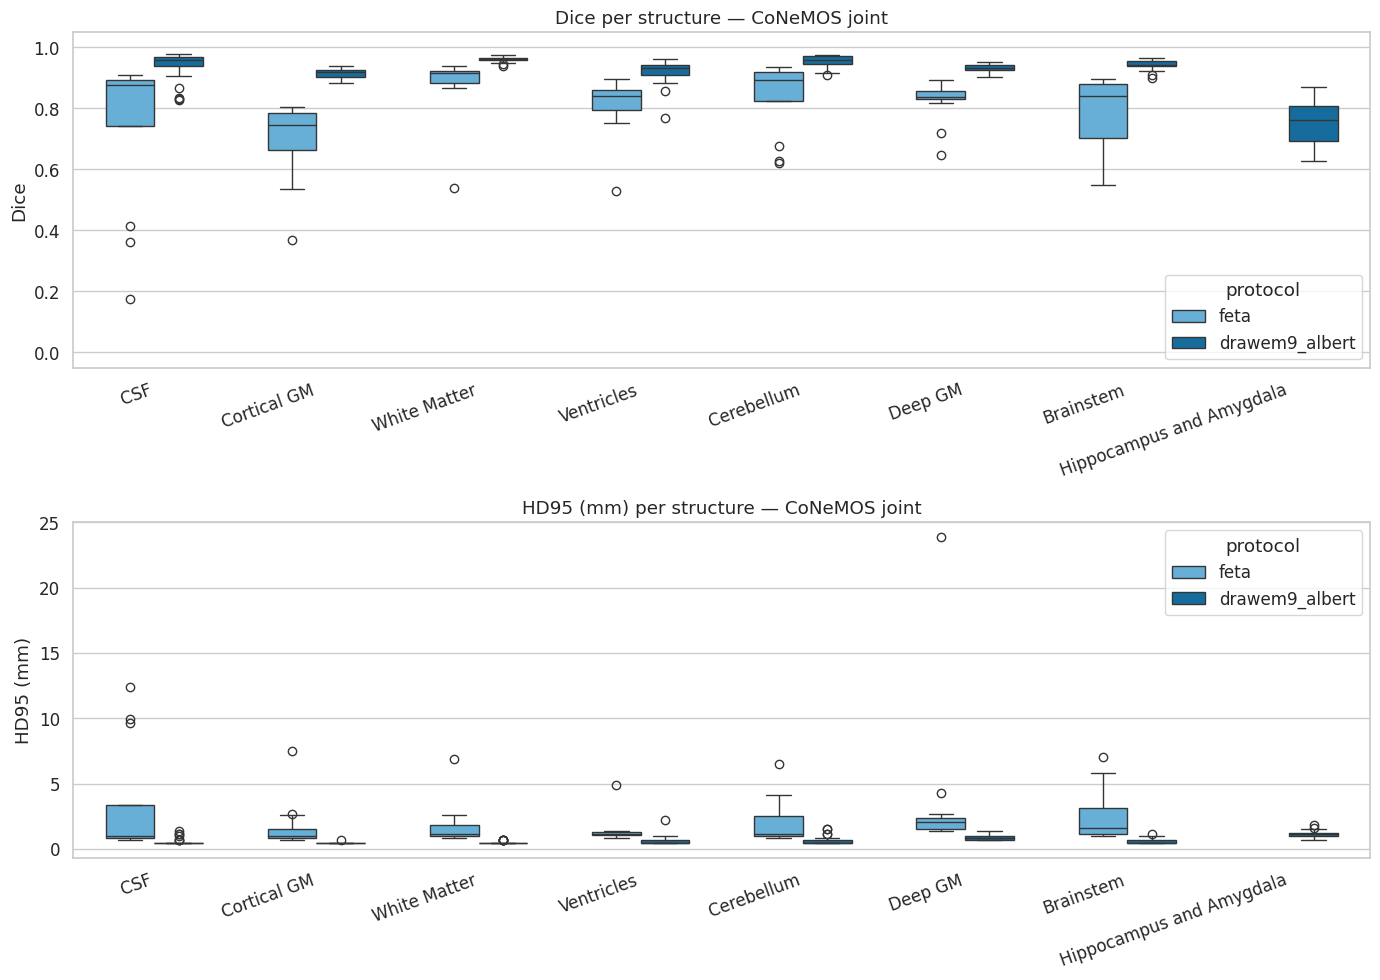

In [236]:
df_dice_long = df.melt(
    id_vars=['subject', 'protocol'],
    value_vars=dice_cols, var_name='ch', value_name='Dice'
)
df_dice_long['Structure'] = df_dice_long['ch'].map(DICE_RENAME)

df_hd95_long = df.melt(
    id_vars=['subject', 'protocol'],
    value_vars=hd95_cols, var_name='ch', value_name='HD95 (mm)'
)
df_hd95_long['Structure'] = df_hd95_long['ch'].map(dict(zip(hd95_cols, struct_names)))

has_hd95 = df['mean_hd95'].notna().any()
nrows    = 2 if has_hd95 else 1
fig, axes = plt.subplots(nrows, 1, figsize=(14, 5 * nrows))
if nrows == 1:
    axes = [axes]

sns.boxplot(data=df_dice_long, x='Structure', y='Dice',
            hue='protocol', palette=palette, width=0.6, ax=axes[0])
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title(f'Dice per structure — {FOCUS_MODEL}')
axes[0].set_xlabel('')
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

if has_hd95:
    sns.boxplot(data=df_hd95_long, x='Structure', y='HD95 (mm)',
                hue='protocol', palette=palette, width=0.6, ax=axes[1])
    axes[1].set_title(f'HD95 (mm) per structure — {FOCUS_MODEL}')
    axes[1].set_xlabel('')
    plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

## Mean Dice & HD95 Distributions

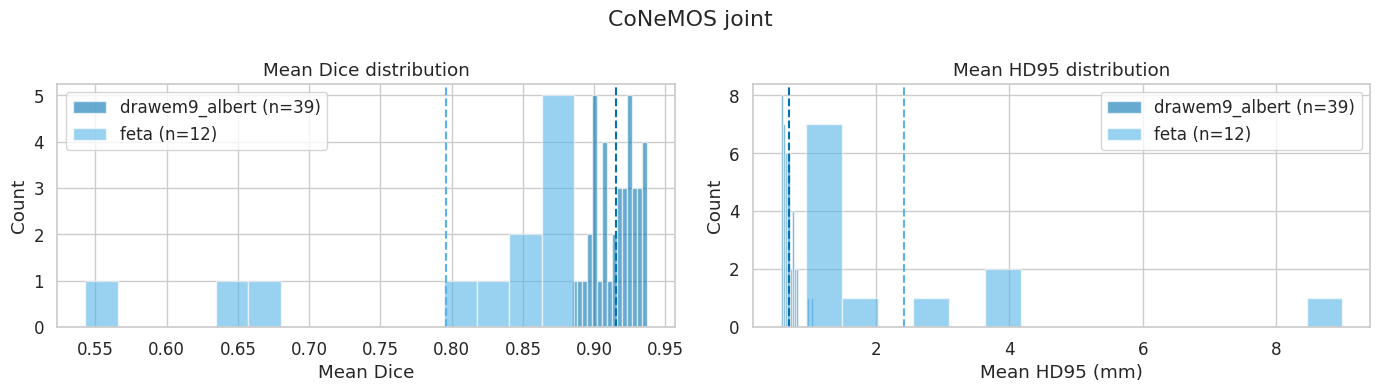

In [237]:
ncols = 2 if df['mean_hd95'].notna().any() else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4))
if ncols == 1:
    axes = [axes]

for proto, color in palette.items():
    sub    = df[df.protocol == proto]
    d_vals = sub['mean_dice'].dropna()
    h_vals = sub['mean_hd95'].dropna()
    label  = f'{proto} (n={len(d_vals)})'
    axes[0].hist(d_vals, bins=15, alpha=0.6, color=color, label=label)
    axes[0].axvline(d_vals.mean(), color=color, linestyle='--', linewidth=1.5)
    if ncols > 1 and len(h_vals):
        axes[1].hist(h_vals, bins=15, alpha=0.6, color=color, label=label)
        axes[1].axvline(h_vals.mean(), color=color, linestyle='--', linewidth=1.5)

axes[0].set(xlabel='Mean Dice', ylabel='Count', title='Mean Dice distribution')
if ncols > 1:
    axes[1].set(xlabel='Mean HD95 (mm)', ylabel='Count', title='Mean HD95 distribution')
for ax in axes:
    ax.legend()
fig.suptitle(FOCUS_MODEL)
plt.tight_layout()
plt.show()

## Worst and Best Subjects

In [238]:
n = 5
for proto in protocols:
    sub = df[df.protocol == proto].rename(columns=DICE_RENAME).copy()
    display_cols = ['subject', 'protocol', 'mean_dice', 'mean_hd95'] + struct_names
    print(f'=== {proto} — WORST {n} ===')
    display(sub.nsmallest(n, 'mean_dice')[display_cols].round(3))
    print(f'\n=== {proto} — BEST {n} ===')
    display(sub.nlargest(n, 'mean_dice')[display_cols].round(3))
    print()

=== drawem9_albert — WORST 5 ===


,subject,protocol,mean_dice,mean_hd95,CSF,Cortical GM,White Matter,Ventricles,Cerebellum,Deep GM,Brainstem,Hippocampus and Amygdala
17,sub-CC00935XX20_ses-20432,drawem9_albert,0.885,0.818,0.830,0.882,0.957,0.902,0.915,0.930,0.901,0.761
23,sub-CC00990XX18_ses-34630,drawem9_albert,0.889,0.729,0.949,0.888,0.949,0.909,0.947,0.909,0.929,0.627
34,sub-CC01060XX05_ses-62931,drawem9_albert,0.893,0.756,0.833,0.882,0.960,0.931,0.945,0.911,0.939,0.739
41,sub-CC01140XX11_ses-96730,drawem9_albert,0.897,0.598,0.931,0.885,0.958,0.895,0.950,0.920,0.960,0.677
28,sub-CC01019XX13_ses-46330,drawem9_albert,0.898,0.640,0.955,0.911,0.947,0.912,0.941,0.907,0.941,0.671



=== drawem9_albert — BEST 5 ===


,subject,protocol,mean_dice,mean_hd95,CSF,Cortical GM,White Matter,Ventricles,Cerebellum,Deep GM,Brainstem,Hippocampus and Amygdala
21,sub-CC00972XX16_ses-26630,drawem9_albert,0.937,0.578,0.969,0.919,0.956,0.946,0.971,0.949,0.962,0.824
12,sub-CC00865XX16_ses-621,drawem9_albert,0.936,0.572,0.969,0.928,0.960,0.940,0.972,0.951,0.957,0.814
33,sub-CC01055XX08_ses-62130,drawem9_albert,0.935,0.711,0.963,0.924,0.958,0.951,0.954,0.939,0.943,0.850
43,sub-CC01172XX10_ses-111630,drawem9_albert,0.935,0.634,0.974,0.918,0.963,0.961,0.965,0.946,0.966,0.789
40,sub-CC01140XX11_ses-115230,drawem9_albert,0.933,0.660,0.959,0.932,0.959,0.887,0.976,0.950,0.947,0.854



=== feta — WORST 5 ===


,subject,protocol,mean_dice,mean_hd95,CSF,Cortical GM,White Matter,Ventricles,Cerebellum,Deep GM,Brainstem,Hippocampus and Amygdala
0,sub-009,feta,0.543,8.995,0.413,0.368,0.539,0.529,0.627,0.648,0.677,NaN
5,sub-020,feta,0.643,4.021,0.174,0.536,0.866,0.751,0.676,0.836,0.665,NaN
3,sub-016,feta,0.664,4.058,0.363,0.553,0.871,0.856,0.621,0.835,0.550,NaN
1,sub-011,feta,0.799,2.587,0.874,0.716,0.887,0.814,0.873,0.719,0.713,NaN
4,sub-018,feta,0.832,1.564,0.852,0.701,0.910,0.851,0.890,0.818,0.805,NaN



=== feta — BEST 5 ===


,subject,protocol,mean_dice,mean_hd95,CSF,Cortical GM,White Matter,Ventricles,Cerebellum,Deep GM,Brainstem,Hippocampus and Amygdala
9,sub-053,feta,0.886,1.019,0.900,0.792,0.934,0.873,0.931,0.893,0.881,NaN
10,sub-057,feta,0.883,1.040,0.898,0.793,0.938,0.873,0.918,0.867,0.896,NaN
8,sub-045,feta,0.881,0.949,0.909,0.804,0.925,0.894,0.904,0.847,0.885,NaN
11,sub-061,feta,0.864,1.309,0.849,0.773,0.923,0.830,0.936,0.855,0.882,NaN
6,sub-026,feta,0.863,1.171,0.885,0.747,0.922,0.852,0.918,0.882,0.838,NaN


## Heatmap — per-subject Dice (sorted by mean)

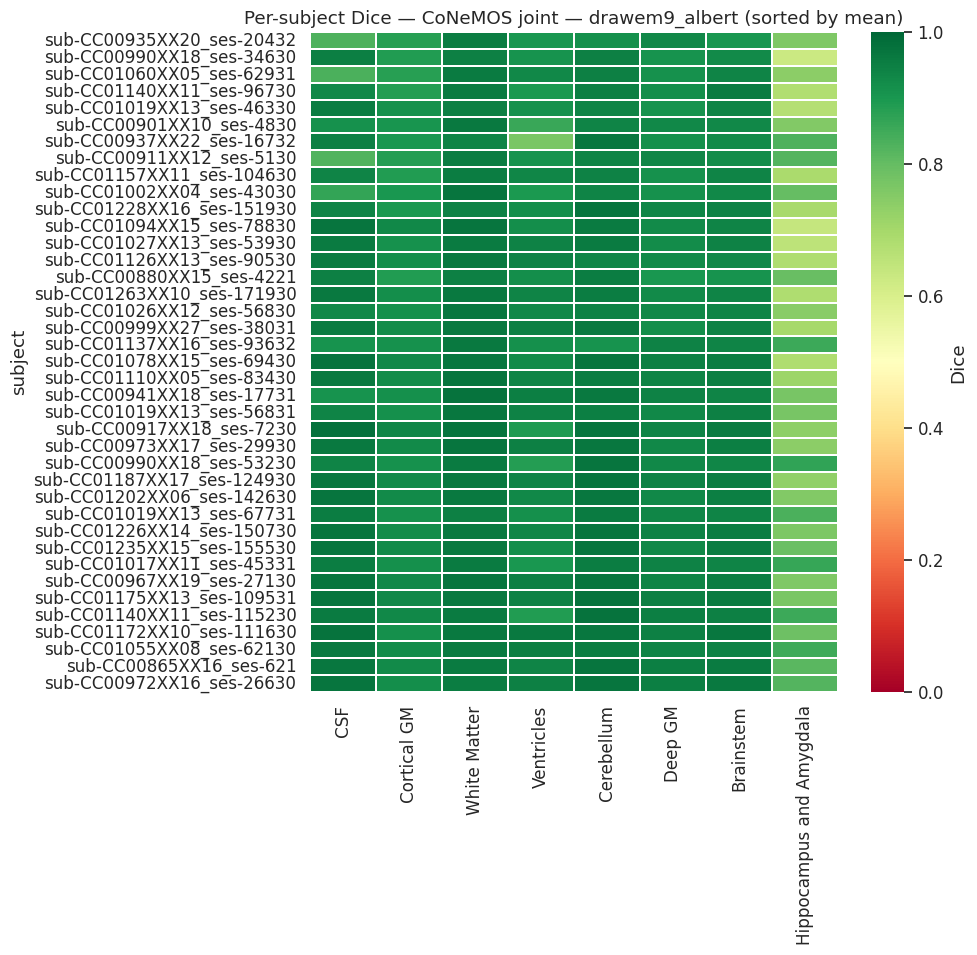

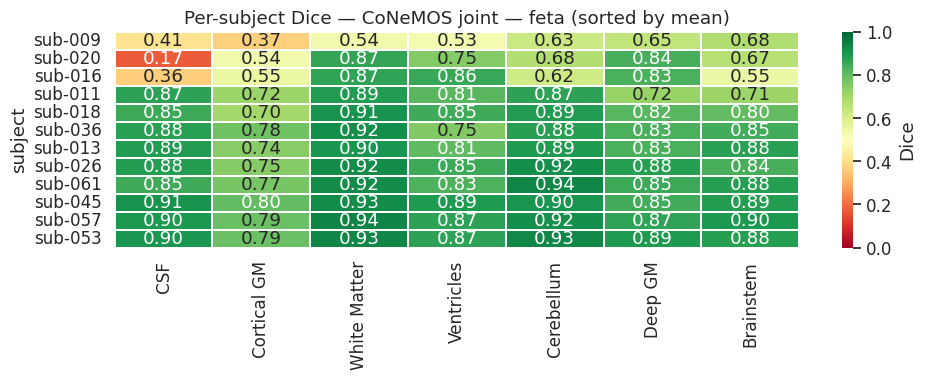

In [239]:
for proto in protocols:
    sub = df[df.protocol == proto].copy().rename(columns=DICE_RENAME)
    available = [c for c in struct_names if sub[c].notna().any()]
    sub = sub.sort_values('mean_dice').set_index('subject')[available]

    fig, ax = plt.subplots(figsize=(10, max(4, len(sub) * 0.25)))
    sns.heatmap(sub, vmin=0, vmax=1, cmap='RdYlGn', linewidths=0.3,
                annot=len(sub) <= 20, fmt='.2f', ax=ax,
                cbar_kws={'label': 'Dice'})
    ax.set_title(f'Per-subject Dice — {FOCUS_MODEL} — {proto} (sorted by mean)')
    plt.tight_layout()
    plt.show()

## Dice vs Gestational Age

In [240]:
GA_SOURCES = {
    'feta': {
        'path':        '/media/danielaco/HDD2TB/DataDaniela/feta_2.4/participants.tsv',
        'sep':         '\t',
        'id_col':      'participant_id',
        'ga_col':      'gestational_age',
        'has_session': False,
    },
    'drawem9_albert': {
        'path':        '/media/danielaco/HDD2TB/DataDaniela/fetalDHCP/resampled05/participants.csv',
        'sep':         ',',
        'id_col':      'participant_id',
        'ga_col':      'GA',
        'ses_col':     'session_id',
        'has_session': True,
    },
}


def _parse_subject(subject, has_session):
    if has_session and '_ses-' in subject:
        pid, ses = subject.rsplit('_ses-', 1)
        return pid, int(ses)
    return subject, None


def _attach_ga(d):
    parts = []
    for proto, src in GA_SOURCES.items():
        if proto not in d.protocol.values:
            continue
        meta = pd.read_csv(src['path'], sep=src['sep'])
        meta = meta.rename(columns={src['id_col']: 'participant_id', src['ga_col']: 'GA'})
        sub  = d[d.protocol == proto].copy()
        parsed = sub.apply(
            lambda r: _parse_subject(r['subject'], src['has_session']),
            axis=1, result_type='expand'
        ).rename(columns={0: 'participant_id', 1: 'session_id'})
        sub = pd.concat([sub, parsed], axis=1)
        if src['has_session']:
            meta = meta.rename(columns={src['ses_col']: 'session_id'})
            meta['session_id'] = meta['session_id'].astype(int)
            sub = sub.merge(meta[['participant_id', 'session_id', 'GA']],
                            on=['participant_id', 'session_id'], how='left')
        else:
            sub = sub.merge(meta[['participant_id', 'GA']],
                            on='participant_id', how='left')
        parts.append(sub)
    return pd.concat(parts, ignore_index=True) if parts else d.copy()


df_ga = _attach_ga(df)
print(f'Missing GA: {df_ga["GA"].isna().sum()} / {len(df_ga)}')
df_ga[['subject', 'protocol', 'GA', 'mean_dice', 'mean_hd95']].head()

Missing GA: 0 / 51


,subject,protocol,GA,mean_dice,mean_hd95
0,sub-009,feta,29.0,0.542996,8.995394
1,sub-011,feta,27.6,0.799409,2.586642
2,sub-013,feta,27.5,0.849097,1.215204
3,sub-016,feta,23.3,0.664173,4.057609
4,sub-018,feta,28.5,0.832368,1.563744


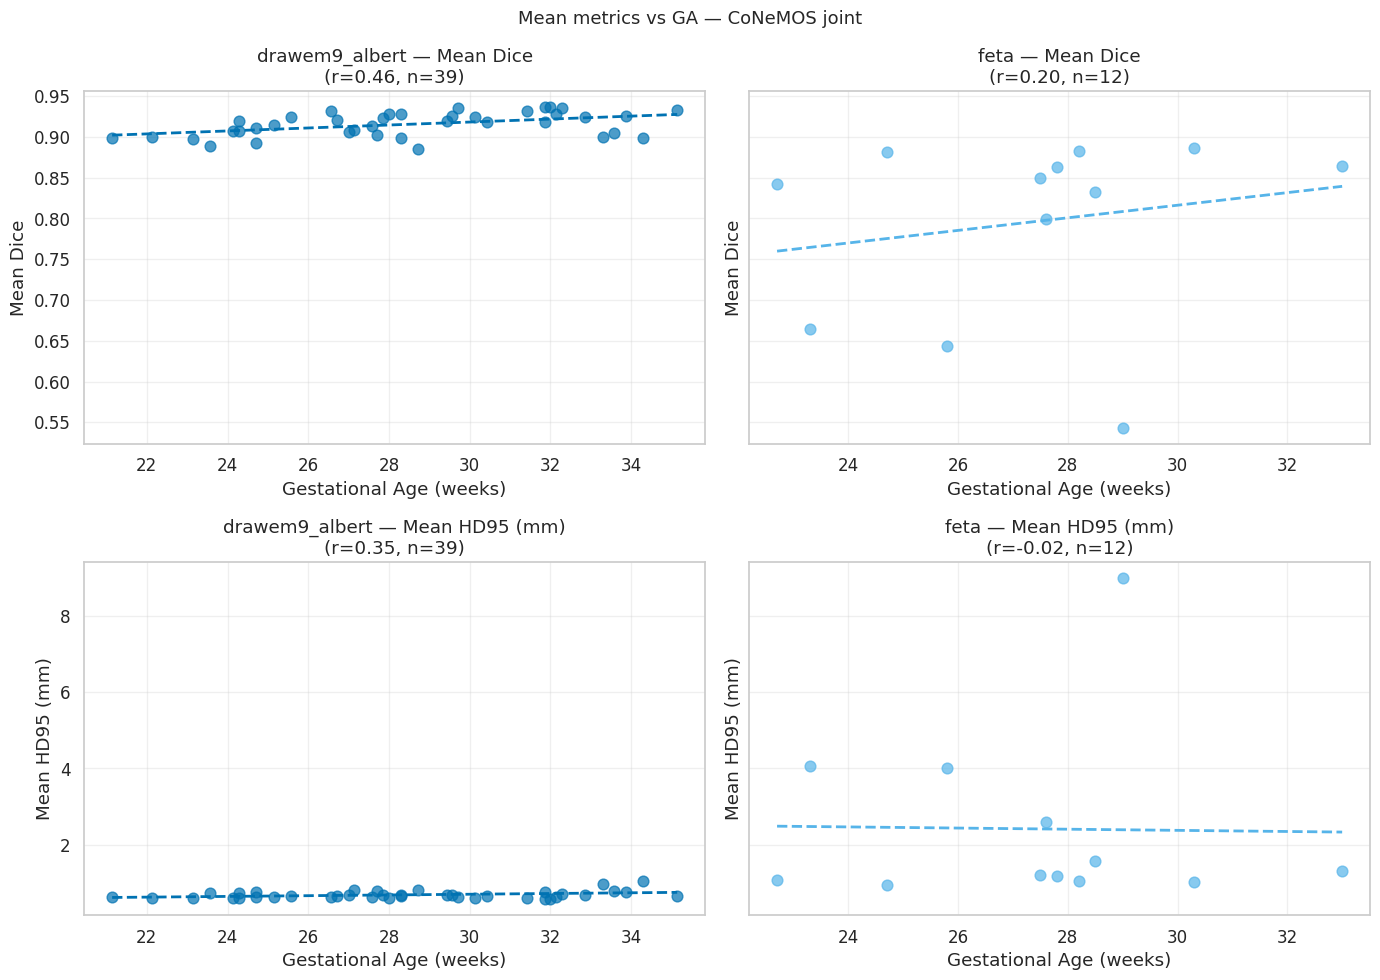

In [241]:
has_hd95 = df_ga['mean_hd95'].notna().any()
nrows    = 2 if has_hd95 else 1
metrics  = [('mean_dice', 'Mean Dice')] + ([('mean_hd95', 'Mean HD95 (mm)')] if has_hd95 else [])

fig, axes = plt.subplots(nrows, len(protocols),
                          figsize=(7 * len(protocols), 5 * nrows),
                          sharey='row', squeeze=False)

for col_i, proto in enumerate(protocols):
    sub   = df_ga[df_ga.protocol == proto].dropna(subset=['GA'])
    color = palette[proto]
    for row_i, (metric, ylabel) in enumerate(metrics):
        ax   = axes[row_i][col_i]
        vals = sub[metric].dropna()
        ga   = sub.loc[vals.index, 'GA']
        ax.scatter(ga, vals, color=color, alpha=0.7, s=60)
        if len(vals) > 2:
            z  = np.polyfit(ga, vals, 1)
            xl = np.linspace(ga.min(), ga.max(), 100)
            ax.plot(xl, np.polyval(z, xl), color=color, linestyle='--', linewidth=2)
            r  = np.corrcoef(ga, vals)[0, 1]
            ax.set_title(f'{proto} — {ylabel}\n(r={r:.2f}, n={len(vals)})')
        ax.set_xlabel('Gestational Age (weeks)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

fig.suptitle(f'Mean metrics vs GA — {FOCUS_MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

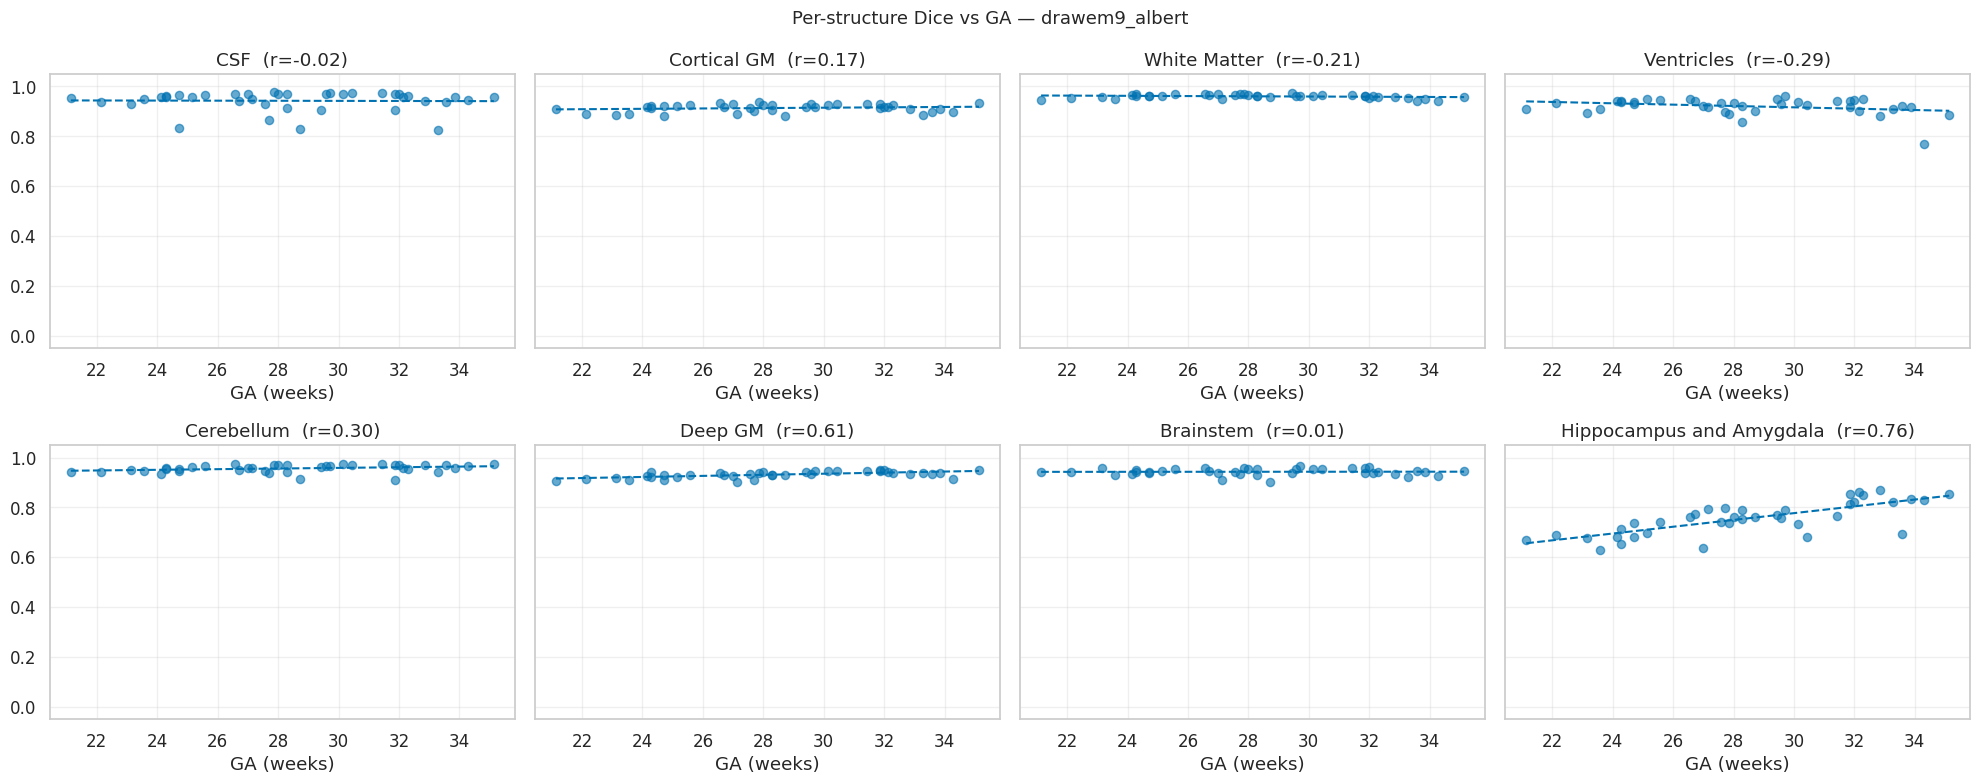

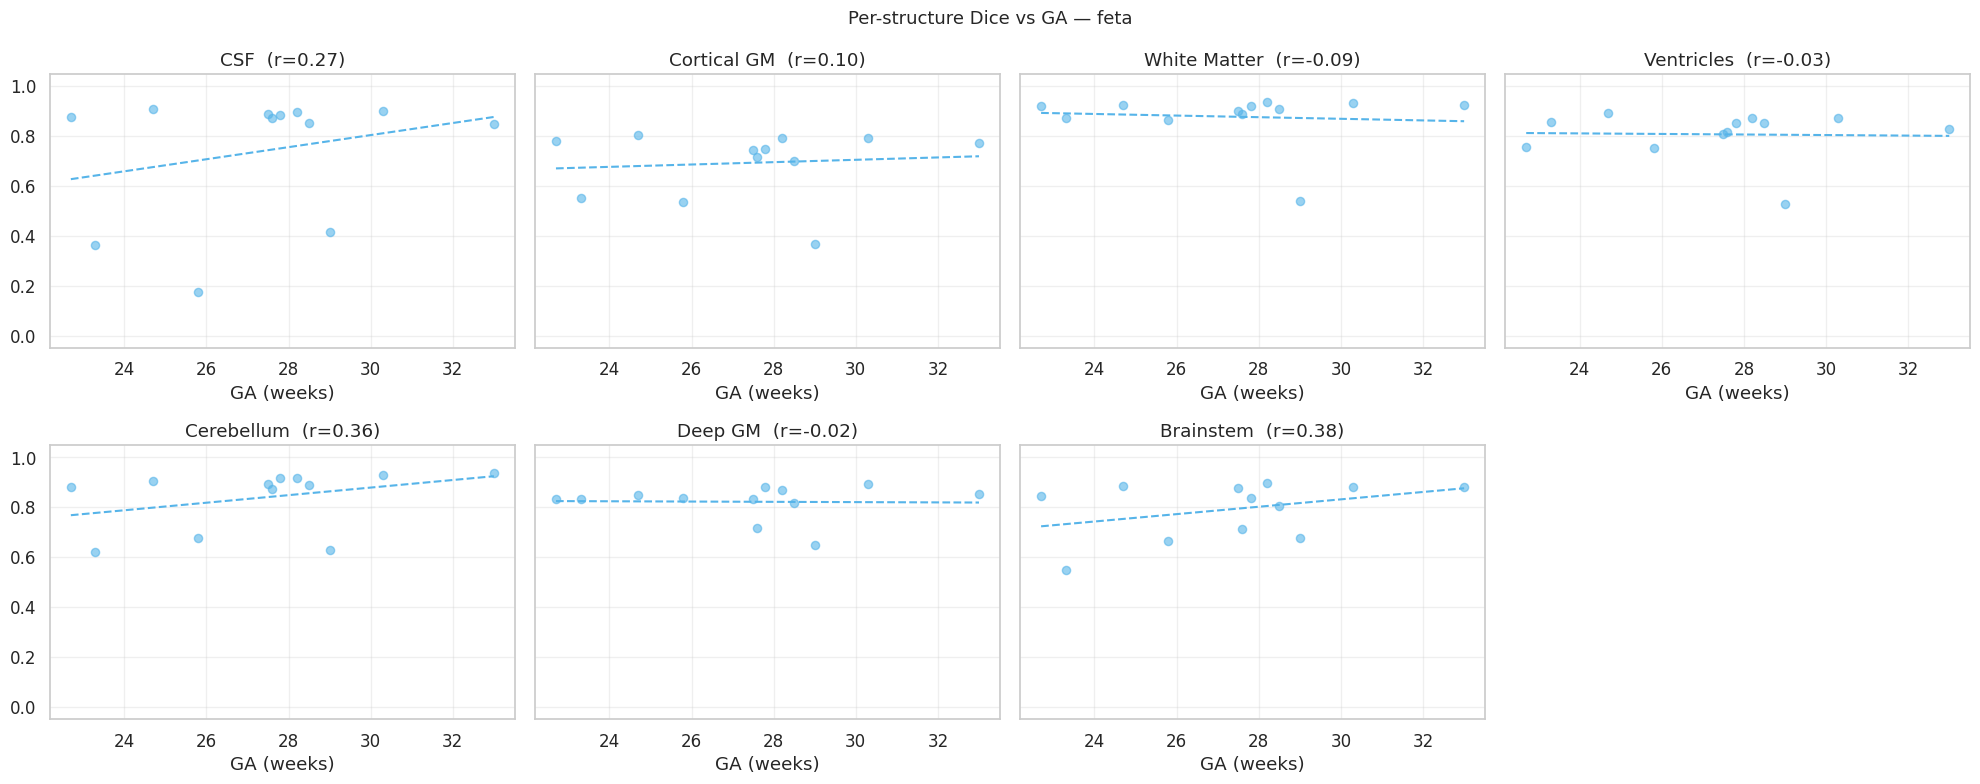

In [242]:
# Per-structure Dice vs GA
ncols = 4
nrows = (len(struct_names) + ncols - 1) // ncols

for proto in protocols:
    sub       = df_ga[df_ga.protocol == proto].dropna(subset=['GA']).rename(columns=DICE_RENAME)
    color     = palette[proto]
    available = [s for s in struct_names if sub[s].notna().any()]

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
    axes = axes.flatten()

    for i, struct in enumerate(available):
        ax   = axes[i]
        vals = sub[struct].dropna()
        ga   = sub.loc[vals.index, 'GA']
        ax.scatter(ga, vals, color=color, alpha=0.6, s=35)
        if len(vals) > 2:
            z  = np.polyfit(ga, vals, 1)
            xl = np.linspace(ga.min(), ga.max(), 100)
            ax.plot(xl, np.polyval(z, xl), color=color, linewidth=1.5, linestyle='--')
            r  = np.corrcoef(ga, vals)[0, 1]
            ax.set_title(f'{struct}  (r={r:.2f})')
        ax.set_xlabel('GA (weeks)')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Per-structure Dice vs GA — {proto}', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Model Comparison
Add all model paths to the `RESULTS` dict in the Load cell, then re-run from the top.

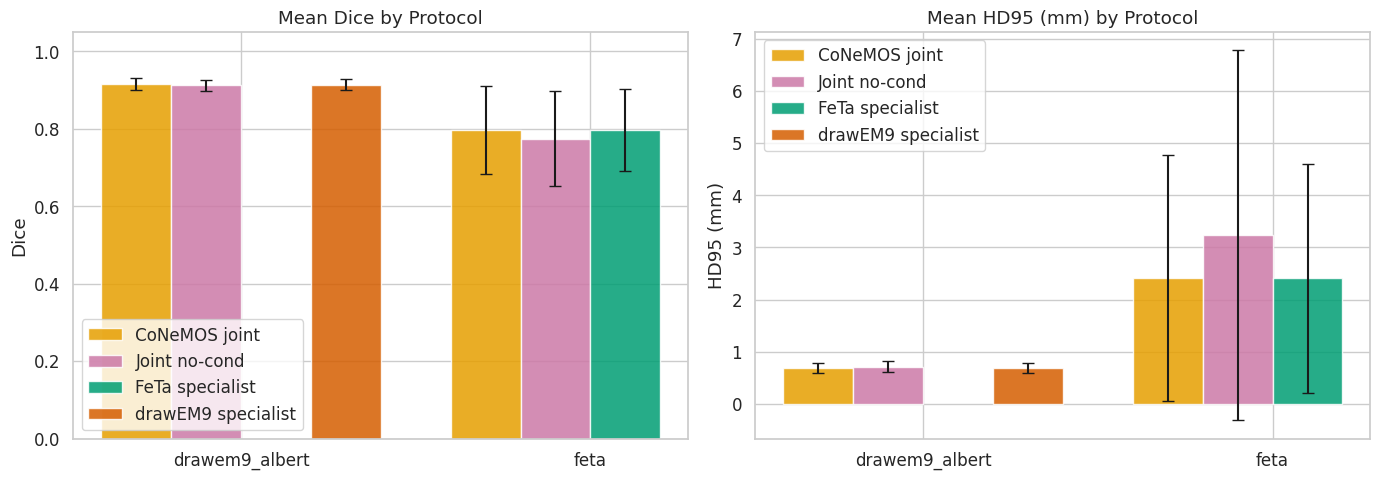

,Model,Protocol,Mean Dice,Dice std,Mean HD95,HD95 std,N
0,CoNeMOS joint,drawem9_albert,0.9155,0.0145,0.6873,0.1003,39
1,CoNeMOS joint,feta,0.7959,0.1141,2.4171,2.3610,12
2,Joint no-cond,drawem9_albert,0.9122,0.0148,0.7151,0.1111,39
3,Joint no-cond,feta,0.7747,0.1217,3.2333,3.5430,12
4,FeTa specialist,feta,0.7971,0.1061,2.4092,2.1956,12
5,drawEM9 specialist,drawem9_albert,0.9142,0.0151,0.6906,0.1021,39


In [243]:
# Overall mean Dice and HD95 per model per protocol
comp_rows = []
for model_name, d in dfs.items():
    for proto in sorted(d.protocol.unique()):
        sub = d[d.protocol == proto]
        comp_rows.append({
            'Model':     model_name,
            'Protocol':  proto,
            'Mean Dice': sub['mean_dice'].mean(),
            'Dice std':  sub['mean_dice'].std(),
            'Mean HD95': sub['mean_hd95'].mean(),
            'HD95 std':  sub['mean_hd95'].std(),
            'N':         len(sub),
        })
comp_overall = pd.DataFrame(comp_rows)

has_hd95  = df['mean_hd95'].notna().any()
n_models  = len(dfs)
width     = 0.8 / n_models
x         = np.arange(len(protocols))
ncols     = 2 if has_hd95 else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
if ncols == 1:
    axes = [axes]

for i, (model_name, color) in enumerate(model_palette.items()):
    for ax, metric, err_col, ylabel, ylim in [
        (axes[0], 'Mean Dice', 'Dice std', 'Dice', (0, 1.05)),
    ] + ([
        (axes[1], 'Mean HD95', 'HD95 std', 'HD95 (mm)', None),
    ] if has_hd95 else []):
        vals = []
        errs = []
        for proto in protocols:
            row = comp_overall[(comp_overall.Model == model_name) &
                               (comp_overall.Protocol == proto)]
            vals.append(row[metric].values[0] if len(row) else np.nan)
            errs.append(row[err_col].values[0] if len(row) else 0)
        ax.bar(x + i * width, vals, width, label=model_name,
               color=color, yerr=errs, capsize=4, alpha=0.85)

for ax, title, ylabel, ylim in [
    (axes[0], 'Mean Dice by Protocol', 'Dice', (0, 1.05)),
] + ([
    (axes[1], 'Mean HD95 (mm) by Protocol', 'HD95 (mm)', None),
] if has_hd95 else []):
    ax.set_xticks(x + width * (n_models - 1) / 2)
    ax.set_xticklabels(protocols)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    if ylim:
        ax.set_ylim(*ylim)

plt.tight_layout()
plt.show()
display(comp_overall.round(4))

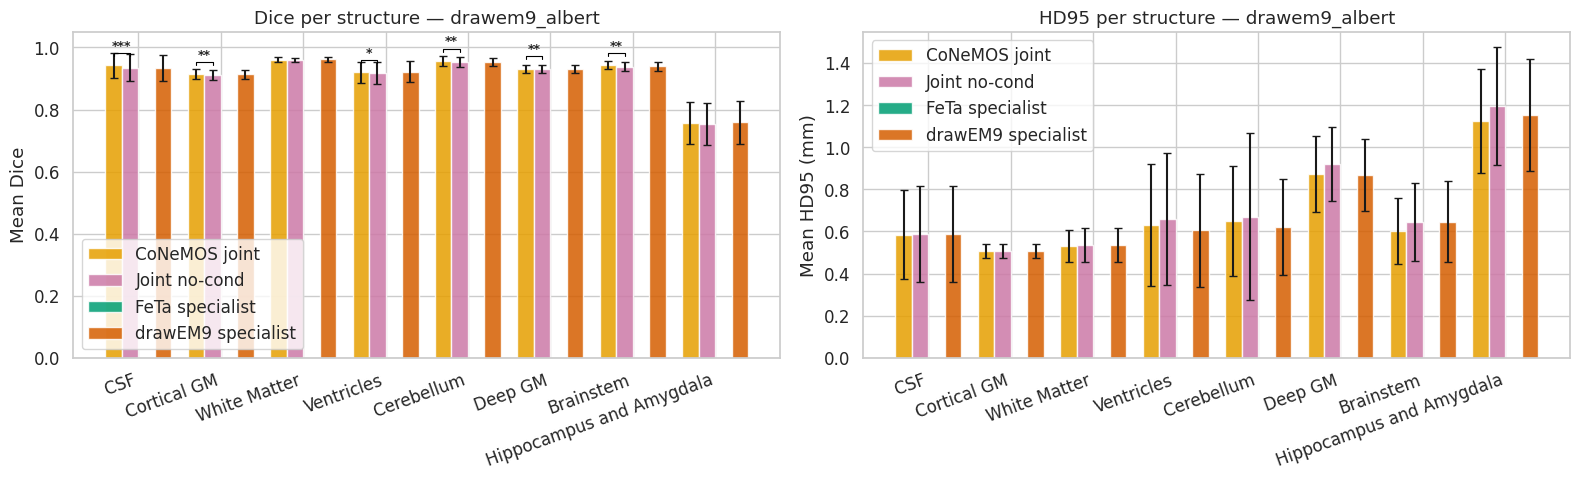

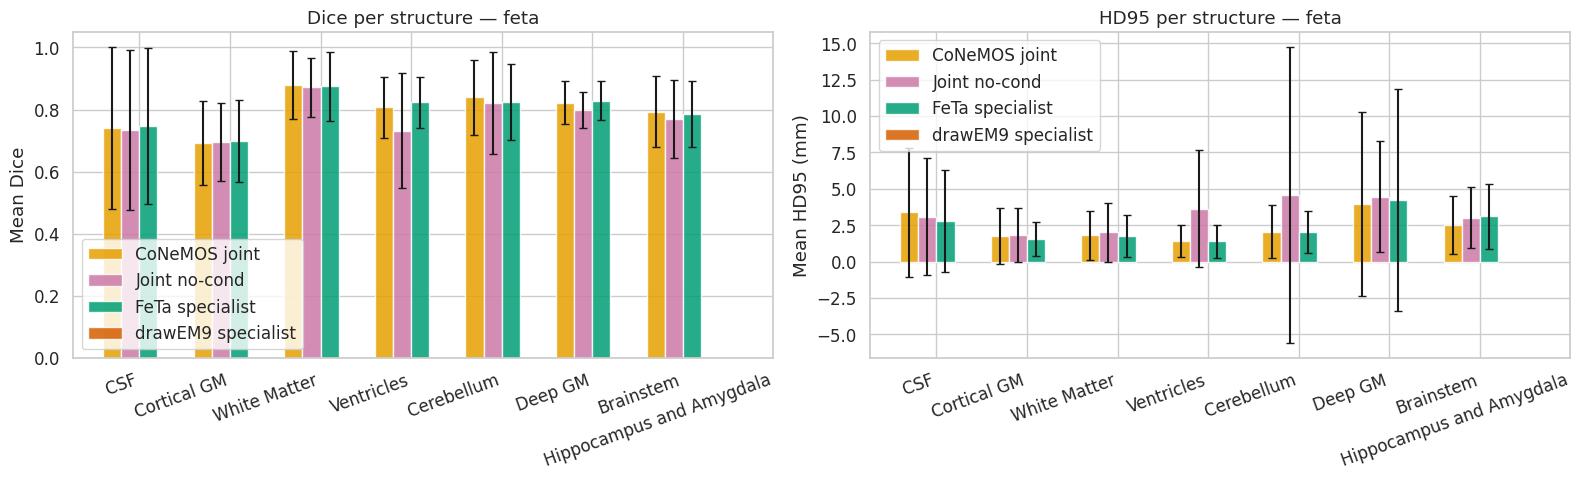

In [244]:
# Per-structure Dice & HD95 comparison — one chart per protocol
# Significance markers (* p<0.05  ** p<0.01  *** p<0.001, BH-corrected) are added
# between every consecutive model pair when ≥2 models are loaded.
struct_rows = []
for model_name, d in dfs.items():
    for proto in sorted(d.protocol.unique()):
        sub = d[d.protocol == proto]
        for dc, hc, name in zip(dice_cols, hd95_cols, struct_names):
            d_vals = sub[dc].dropna()
            h_vals = sub[hc].dropna()
            if len(d_vals) == 0:
                continue
            struct_rows.append({
                'Model':     model_name,
                'Protocol':  proto,
                'Structure': name,
                'Dice mean': d_vals.mean(),
                'Dice std':  d_vals.std(),
                'HD95 mean': h_vals.mean() if len(h_vals) else np.nan,
                'HD95 std':  h_vals.std()  if len(h_vals) else np.nan,
            })
struct_comp = pd.DataFrame(struct_rows)
has_hd95    = df['mean_hd95'].notna().any()
ncols       = 2 if has_hd95 else 1


def _sig_stars(p):
    if np.isnan(p): return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return ''


def _compute_sig_per_structure(base_name, compare_name, proto):
    """Return dict {struct_name: BH-adjusted p-value} for one comparison × protocol."""
    base_d = dfs[base_name][dfs[base_name].protocol == proto].set_index('subject')
    comp_d = dfs[compare_name][dfs[compare_name].protocol == proto].set_index('subject')
    shared = base_d.index.intersection(comp_d.index)
    paired = len(shared) >= 5

    p_vals = {}
    for dc, name in zip(dice_cols, struct_names):
        if paired:
            idx = base_d[dc].dropna().index.intersection(comp_d[dc].dropna().index)
            if len(idx) < 5:
                p_vals[name] = np.nan
                continue
            a_v = base_d.loc[idx, dc].values
            b_v = comp_d.loc[idx, dc].values
            try:
                _, p = wilcoxon(a_v, b_v)
            except Exception:
                p = np.nan
        else:
            a_v = base_d[dc].dropna().values
            b_v = comp_d[dc].dropna().values
            if len(a_v) < 5 or len(b_v) < 5:
                p_vals[name] = np.nan
                continue
            try:
                _, p = mannwhitneyu(a_v, b_v, alternative='two-sided')
            except Exception:
                p = np.nan
        p_vals[name] = p

    # BH correction across all structures in this block
    names_arr = list(p_vals.keys())
    p_arr     = np.array([p_vals[n] for n in names_arr], dtype=float)
    valid     = ~np.isnan(p_arr)
    if valid.sum() > 1:
        p_adj = np.full(len(p_arr), np.nan)
        p_adj[valid] = false_discovery_control(p_arr[valid], method='bh')
    else:
        p_adj = p_arr
    return dict(zip(names_arr, p_adj))


for proto in sorted(struct_comp.Protocol.unique()):
    sub_p = struct_comp[struct_comp.Protocol == proto]
    fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    x     = np.arange(len(struct_names))
    width = 0.8 / n_models
    # track bar-top positions for significance bracket drawing
    bar_tops = {s: {} for s in struct_names}

    for i, (model_name, color) in enumerate(model_palette.items()):
        m = sub_p[sub_p.Model == model_name]
        for ax, val_col, err_col in [
            (axes[0], 'Dice mean', 'Dice std'),
        ] + ([(axes[1], 'HD95 mean', 'HD95 std')] if has_hd95 else []):
            vals = [m[m.Structure == s][val_col].values[0]
                    if len(m[m.Structure == s]) else np.nan for s in struct_names]
            errs = [m[m.Structure == s][err_col].values[0]
                    if len(m[m.Structure == s]) else 0    for s in struct_names]
            ax.bar(x + i * width, vals, width, label=model_name,
                   color=color, yerr=errs, capsize=3, alpha=0.85)
            if ax is axes[0]:
                for si, (s, v) in enumerate(zip(struct_names, vals)):
                    if not (isinstance(v, float) and np.isnan(v)):
                        bar_tops[s][model_name] = (x[si] + i * width, v)

    # Significance brackets between consecutive model pairs on the Dice axis
    if n_models >= 2:
        model_names_list = list(dfs.keys())
        ax = axes[0]
        bracket_level = {s: 0 for s in struct_names}  # stacks brackets if >1 comparison

        for base_name, compare_name in zip(model_names_list, model_names_list[1:]):
            p_adj_dict = _compute_sig_per_structure(base_name, compare_name, proto)
            for si, name in enumerate(struct_names):
                star = _sig_stars(p_adj_dict.get(name, np.nan))
                if not star:
                    continue
                if base_name not in bar_tops[name] or compare_name not in bar_tops[name]:
                    continue
                x1, h1 = bar_tops[name][base_name]
                x2, h2 = bar_tops[name][compare_name]
                level  = bracket_level[name]
                h_base = max(h1, h2) + 0.03 + level * 0.06
                ax.plot([x1, x1, x2, x2],
                        [h_base, h_base + 0.01, h_base + 0.01, h_base],
                        color='black', linewidth=0.8)
                ax.text((x1 + x2) / 2, h_base + 0.012, star,
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
                bracket_level[name] += 1

    for ax, title, ylabel, ylim in [
        (axes[0], f'Dice per structure — {proto}', 'Mean Dice', (0, 1.05)),
    ] + ([
        (axes[1], f'HD95 per structure — {proto}', 'Mean HD95 (mm)', None),
    ] if has_hd95 else []):
        ax.set_xticks(x + width * (n_models - 1) / 2)
        ax.set_xticklabels(struct_names, rotation=20, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        if ylim:
            ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()

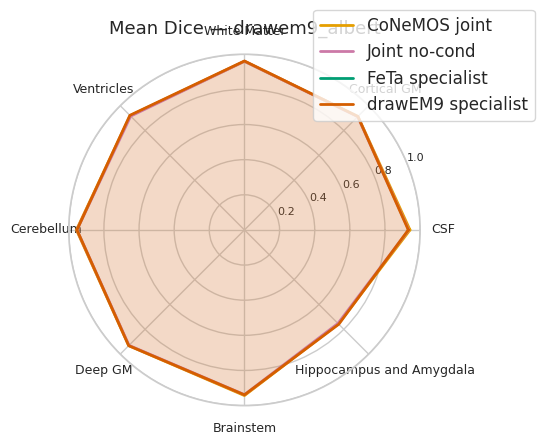

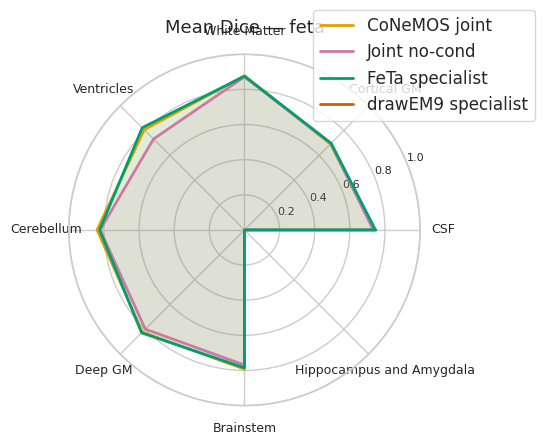

In [245]:
# Radar / spider plot — mean Dice per structure per protocol
def _radar(models_data, proto, struct_names, model_palette):
    N      = len(struct_names)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    for model_name, vals in models_data.items():
        v = [v if not np.isnan(v) else 0 for v in vals]
        v = v + [v[0]]
        color = model_palette[model_name]
        ax.plot(angles, v, color=color, linewidth=2, label=model_name)
        ax.fill(angles, v, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(struct_names, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
    ax.set_title(f'Mean Dice — {proto}', size=13, pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    plt.tight_layout()
    plt.show()


for proto in protocols:
    models_data = {}
    for model_name, d in dfs.items():
        sub  = d[d.protocol == proto]
        vals = [sub[dc].mean() if len(sub[dc].dropna()) else np.nan for dc in dice_cols]
        models_data[model_name] = vals
    _radar(models_data, proto, struct_names, model_palette)

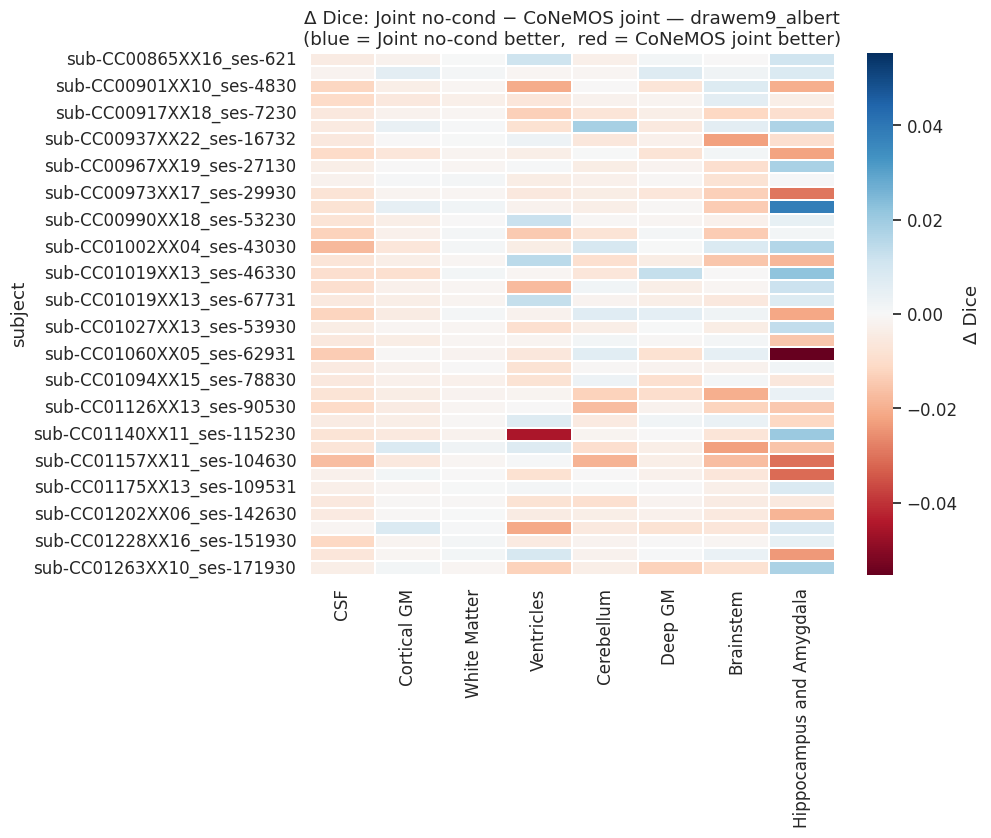

/tmp/ipykernel_3299802/2014221565.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


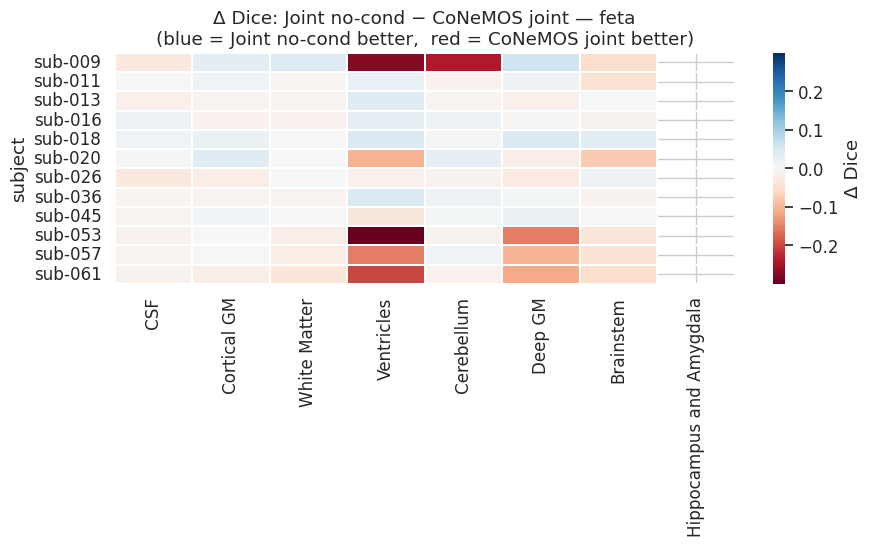

No shared subjects: FeTa specialist vs CoNeMOS joint on drawem9_albert


/tmp/ipykernel_3299802/2014221565.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


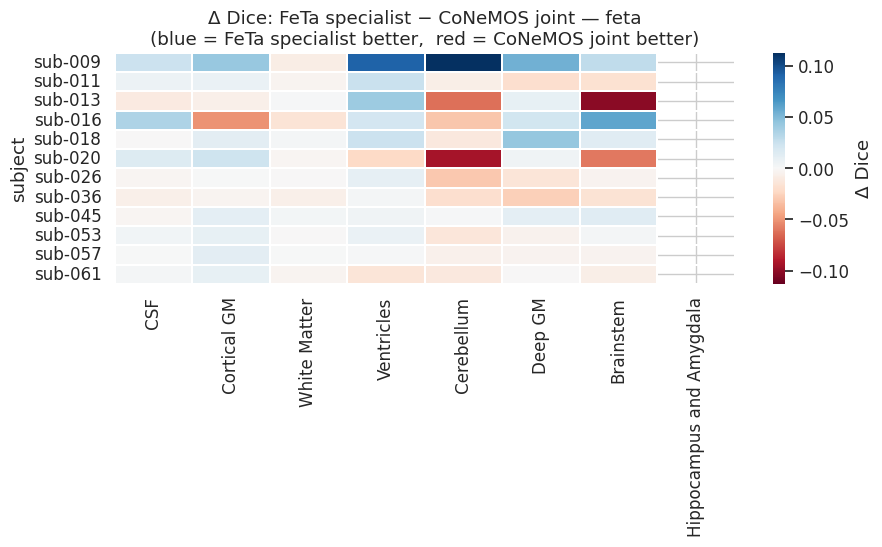

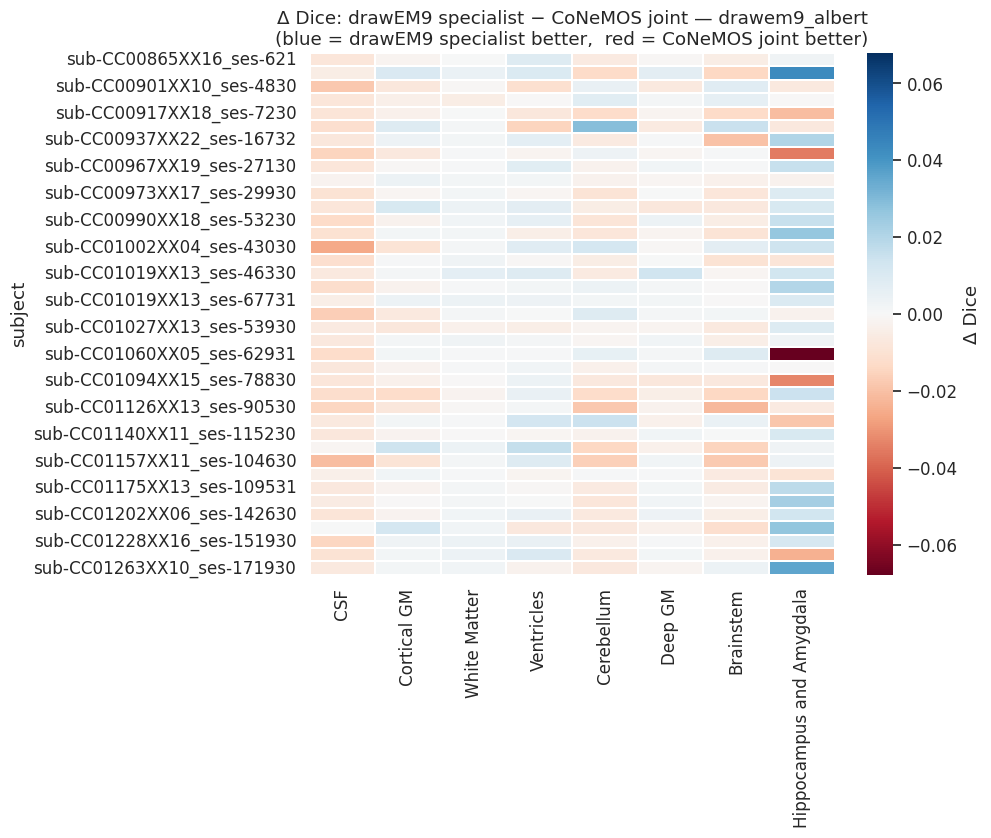

No shared subjects: drawEM9 specialist vs CoNeMOS joint on feta


In [246]:
# Δ Dice heatmap — each model vs the baseline
BASELINE    = list(dfs.keys())[0]
model_names = list(dfs.keys())

if len(model_names) < 2:
    print('Add more models to RESULTS to enable pairwise comparison.')
else:
    for compare_model in model_names[1:]:
        for proto in protocols:
            base_df = dfs[BASELINE][dfs[BASELINE].protocol == proto].set_index('subject')
            comp_df = dfs[compare_model][dfs[compare_model].protocol == proto].set_index('subject')
            shared  = base_df.index.intersection(comp_df.index)
            if len(shared) == 0:
                print(f'No shared subjects: {compare_model} vs {BASELINE} on {proto}')
                continue

            delta = pd.DataFrame(index=shared)
            for dc, name in zip(dice_cols, struct_names):
                if dc in base_df.columns and dc in comp_df.columns:
                    delta[name] = comp_df.loc[shared, dc].values - base_df.loc[shared, dc].values

            vals_flat = delta.values[~np.isnan(delta.values)]
            vmax = max(abs(vals_flat).max(), 0.01) if len(vals_flat) else 0.1
            fig, ax = plt.subplots(figsize=(10, max(3, len(shared) * 0.22)))
            sns.heatmap(delta, center=0, vmin=-vmax, vmax=vmax,
                        cmap='RdBu', linewidths=0.2, ax=ax,
                        cbar_kws={'label': 'Δ Dice'})
            ax.set_title(f'Δ Dice: {compare_model} − {BASELINE} — {proto}\n'
                         f'(blue = {compare_model} better,  red = {BASELINE} better)')
            plt.tight_layout()
            plt.show()

In [247]:
# Statistical significance — Wilcoxon signed-rank (paired) or Mann-Whitney U (unpaired)
# with Benjamini-Hochberg FDR correction and Cliff's delta effect size.
#
# Paired test is used when the two models share ≥5 subjects on a protocol;
# otherwise falls back to Mann-Whitney U.

BASELINE = list(dfs.keys())[0]


def cliffs_delta(a, b):
    """Non-parametric effect size. Positive → b tends to exceed a."""
    n1, n2 = len(a), len(b)
    if n1 == 0 or n2 == 0:
        return np.nan
    return sum(
        1 if bj > ai else (-1 if bj < ai else 0)
        for ai in a for bj in b
    ) / (n1 * n2)


def _pvalue(a_ser, b_ser, paired):
    if paired:
        idx = a_ser.dropna().index.intersection(b_ser.dropna().index)
        if len(idx) < 5:
            return np.nan, np.nan
        a_v, b_v = a_ser.loc[idx].values, b_ser.loc[idx].values
        try:
            _, p = wilcoxon(a_v, b_v)
        except Exception:
            p = np.nan
    else:
        a_v, b_v = a_ser.dropna().values, b_ser.dropna().values
        if len(a_v) < 5 or len(b_v) < 5:
            return np.nan, np.nan
        try:
            _, p = mannwhitneyu(a_v, b_v, alternative='two-sided')
        except Exception:
            p = np.nan
    return a_v, b_v, p


if len(dfs) < 2:
    print('Add more models to RESULTS to run statistical tests.')
    sig_df = pd.DataFrame()
else:
    sig_rows = []
    for compare_model in list(dfs.keys())[1:]:
        for proto in protocols:
            base_d = dfs[BASELINE][dfs[BASELINE].protocol == proto].set_index('subject')
            comp_d = dfs[compare_model][dfs[compare_model].protocol == proto].set_index('subject')
            shared = base_d.index.intersection(comp_d.index)
            paired = len(shared) >= 5
            test_name = 'Wilcoxon' if paired else 'Mann-Whitney U'

            for dc, name in zip(dice_cols, struct_names):
                if paired:
                    idx = base_d[dc].dropna().index.intersection(comp_d[dc].dropna().index)
                    if len(idx) < 5:
                        continue
                    a_v = base_d.loc[idx, dc].values
                    b_v = comp_d.loc[idx, dc].values
                    try:
                        _, p = wilcoxon(a_v, b_v)
                    except Exception:
                        p = np.nan
                else:
                    a_v = base_d[dc].dropna().values
                    b_v = comp_d[dc].dropna().values
                    if len(a_v) < 5 or len(b_v) < 5:
                        continue
                    try:
                        _, p = mannwhitneyu(a_v, b_v, alternative='two-sided')
                    except Exception:
                        p = np.nan

                cd = cliffs_delta(a_v, b_v)
                sig_rows.append({
                    'Comparison':  f'{compare_model} vs {BASELINE}',
                    'Protocol':    proto,
                    'Structure':   name,
                    'Test':        test_name,
                    'N (base)':    len(a_v),
                    'N (comp)':    len(b_v),
                    'Dice (base)': round(float(np.mean(a_v)), 4),
                    'Dice (comp)': round(float(np.mean(b_v)), 4),
                    'Δ Dice':      round(float(np.mean(b_v) - np.mean(a_v)), 4),
                    'p_raw':       round(p, 4) if not np.isnan(p) else np.nan,
                    "Cliff's δ":   round(cd, 3),
                })

    if not sig_rows:
        print('No paired data found — check that models were evaluated on the same subjects.')
        sig_df = pd.DataFrame()
    else:
        sig_df = pd.DataFrame(sig_rows)

        # BH-FDR correction within each comparison × protocol group
        p_adj_all = np.full(len(sig_df), np.nan)
        for _, grp_idx in sig_df.groupby(['Comparison', 'Protocol']).groups.items():
            p_raw = sig_df.loc[grp_idx, 'p_raw'].values.astype(float)
            valid = ~np.isnan(p_raw)
            if valid.sum() > 1:
                p_adj = np.full(len(p_raw), np.nan)
                p_adj[valid] = false_discovery_control(p_raw[valid], method='bh')
            else:
                p_adj = p_raw.copy()
            p_adj_all[list(grp_idx)] = p_adj

        sig_df['p_adj (BH)'] = p_adj_all.round(4)

        def _stars(p):
            if np.isnan(p): return 'n/a'
            if p < 0.001:   return '***'
            if p < 0.01:    return '**'
            if p < 0.05:    return '*'
            return 'ns'

        sig_df['sig'] = sig_df['p_adj (BH)'].apply(_stars)

        display_cols = ['Comparison', 'Protocol', 'Structure', 'Test',
                        'Dice (base)', 'Dice (comp)', 'Δ Dice',
                        'p_raw', 'p_adj (BH)', 'sig', "Cliff's δ"]
        display(sig_df[display_cols]
                .sort_values(['Comparison', 'Protocol', 'Structure'])
                .reset_index(drop=True))

        print('\nSignificance (* p<0.05  ** p<0.01  *** p<0.001) after BH-FDR correction.')
        print("Cliff's δ magnitude: <0.147 negligible · <0.330 small · <0.474 medium · ≥0.474 large")

,Comparison,Protocol,Structure,Test,Dice (base),Dice (comp),Δ Dice,p_raw,p_adj (BH),sig,Cliff's δ
0,FeTa specialist vs CoNeMOS joint,feta,Brainstem,Wilcoxon,0.7928,0.7850,-0.0078,0.5693,0.5693,ns,-0.069
1,FeTa specialist vs CoNeMOS joint,feta,CSF,Wilcoxon,0.7402,0.7458,0.0055,0.3394,0.4752,ns,0.000
2,FeTa specialist vs CoNeMOS joint,feta,Cerebellum,Wilcoxon,0.8390,0.8247,-0.0144,0.0425,0.1827,ns,-0.236
3,FeTa specialist vs CoNeMOS joint,feta,Cortical GM,Wilcoxon,0.6924,0.6979,0.0055,0.0923,0.2154,ns,0.083
4,FeTa specialist vs CoNeMOS joint,feta,Deep GM,Wilcoxon,0.8222,0.8284,0.0062,0.5693,0.5693,ns,0.153
5,FeTa specialist vs CoNeMOS joint,feta,Ventricles,Wilcoxon,0.8070,0.8230,0.0159,0.0522,0.1827,ns,0.208
6,FeTa specialist vs CoNeMOS joint,feta,White Matter,Wilcoxon,0.8778,0.8750,-0.0028,0.1294,0.2264,ns,-0.069
7,Joint no-cond vs CoNeMOS joint,drawem9_albert,Brainstem,Wilcoxon,0.9429,0.9379,-0.0049,0.0012,0.0028,**,-0.201
8,Joint no-cond vs CoNeMOS joint,drawem9_albert,CSF,Wilcoxon,0.9425,0.9351,-0.0074,0.0000,0.0000,***,-0.187
9,Joint no-cond vs CoNeMOS joint,drawem9_albert,Cerebellum,Wilcoxon,0.9565,0.9537,-0.0028,0.0014,0.0028,**,-0.135



Significance (* p<0.05  ** p<0.01  *** p<0.001) after BH-FDR correction.
Cliff's δ magnitude: <0.147 negligible · <0.330 small · <0.474 medium · ≥0.474 large


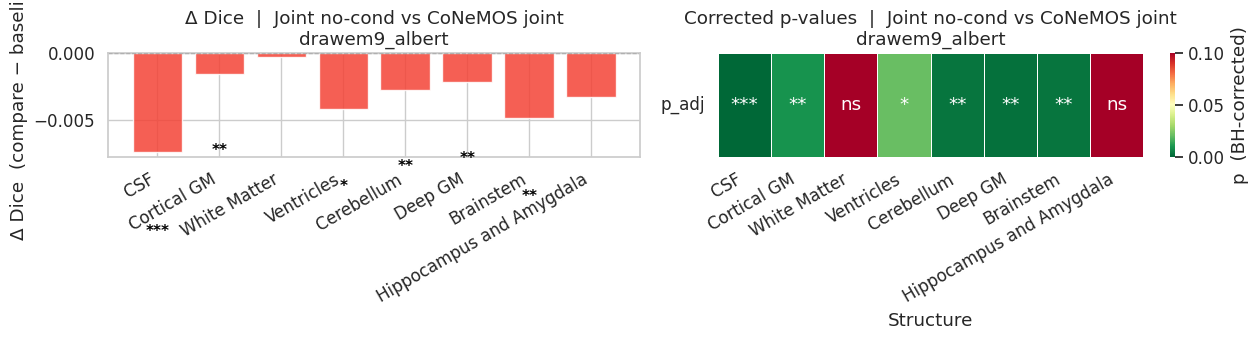

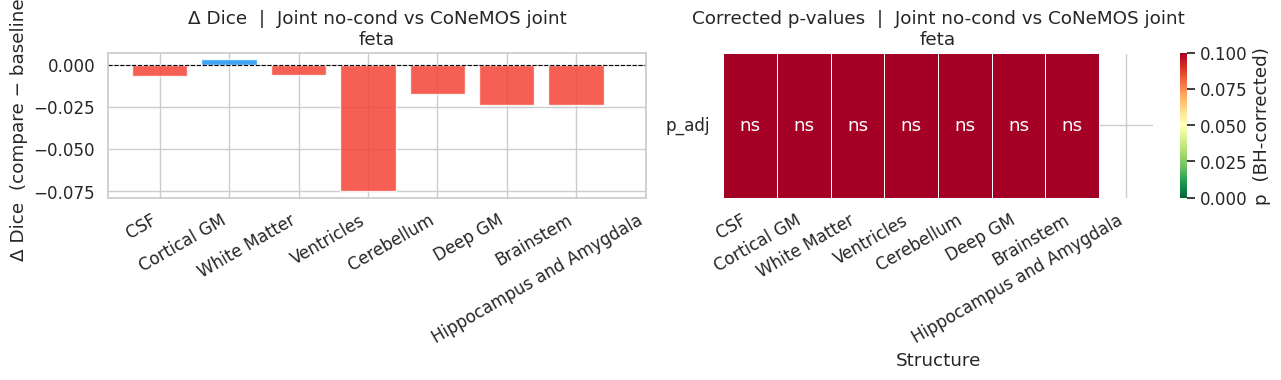

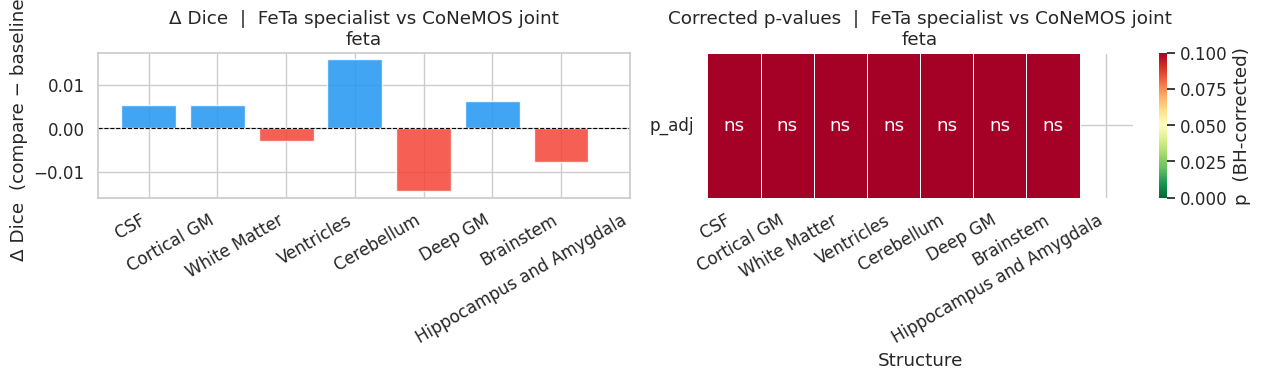

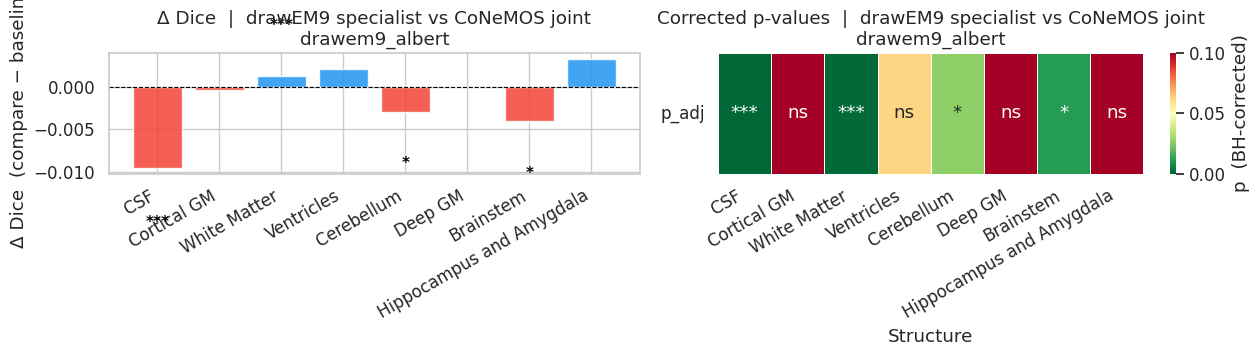

In [248]:
# Significance summary: Δ Dice bar chart (annotated) + p-value heatmap per comparison × protocol
if not sig_df.empty:
    for comparison in sig_df['Comparison'].unique():
        cmp_df = sig_df[sig_df['Comparison'] == comparison]
        for proto in cmp_df['Protocol'].unique():
            sub = (cmp_df[cmp_df['Protocol'] == proto]
                   .set_index('Structure')
                   .reindex(struct_names))

            fig, axes = plt.subplots(1, 2, figsize=(13, 4))

            # ── Left: Δ Dice bar chart with sig stars ──────────────────────
            delta = sub['Δ Dice'].values.astype(float)
            bar_colors = ['#2196F3' if v > 0 else '#F44336' for v in delta]
            axes[0].bar(range(len(struct_names)), delta, color=bar_colors, alpha=0.85)
            axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
            axes[0].set_xticks(range(len(struct_names)))
            axes[0].set_xticklabels(struct_names, rotation=30, ha='right')
            axes[0].set_ylabel('Δ Dice  (compare − baseline)')
            axes[0].set_title(f'Δ Dice  |  {comparison}\n{proto}')

            for i, (v, sig) in enumerate(zip(delta, sub['sig'].values)):
                if sig not in ('ns', 'n/a') and not (isinstance(v, float) and np.isnan(v)):
                    offset = abs(v) * 0.05 + 0.005
                    ypos = v + offset if v >= 0 else v - offset
                    va = 'bottom' if v >= 0 else 'top'
                    axes[0].text(i, ypos, sig, ha='center', va=va,
                                 fontsize=11, fontweight='bold', color='black')

            # ── Right: p-value heatmap (structures × metric) ───────────────
            p_mat = sub[['p_adj (BH)']].T.astype(float)
            annot_mat = np.where(
                sub['sig'].isna(), '',
                sub['sig'].fillna('').values
            ).reshape(1, -1)

            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                sns.heatmap(p_mat, annot=annot_mat, fmt='',
                            cmap='RdYlGn_r', vmin=0, vmax=0.1,
                            linewidths=0.6, linecolor='white',
                            cbar_kws={'label': 'p  (BH-corrected)'},
                            ax=axes[1])
            axes[1].set_xticklabels(struct_names, rotation=30, ha='right')
            axes[1].set_yticklabels(['p_adj'], rotation=0)
            axes[1].set_title(f'Corrected p-values  |  {comparison}\n{proto}')

            plt.tight_layout()
            plt.show()
else:
    print('Run the statistical test cell above first (requires ≥2 models).')

## Summary Comparison Table (LaTeX-ready)

In [249]:
table_rows = []
for model_name, d in dfs.items():
    for proto in sorted(d.protocol.unique()):
        sub = d[d.protocol == proto]
        row = {'Model': model_name, 'Protocol': proto, 'N': len(sub)}
        for dc, hc, name in zip(dice_cols, hd95_cols, struct_names):
            d_vals = sub[dc].dropna()
            h_vals = sub[hc].dropna()
            row[f'{name} Dice'] = f"{d_vals.mean():.3f}" if len(d_vals) else 'n/a'
            row[f'{name} HD95'] = f"{h_vals.mean():.2f}" if len(h_vals) else 'n/a'
        row['Mean Dice'] = (f"{sub['mean_dice'].mean():.3f} "
                            f"± {sub['mean_dice'].std():.3f}")
        row['Mean HD95'] = (f"{sub['mean_hd95'].mean():.2f} "
                            f"± {sub['mean_hd95'].std():.2f}"
                            if sub['mean_hd95'].notna().any() else 'n/a')
        table_rows.append(row)

table_df = pd.DataFrame(table_rows)
compact  = table_df[['Model', 'Protocol', 'N', 'Mean Dice', 'Mean HD95']]
display(compact)
display(table_df)

,Model,Protocol,N,Mean Dice,Mean HD95
0,CoNeMOS joint,drawem9_albert,39,0.916 ± 0.015,0.69 ± 0.10
1,CoNeMOS joint,feta,12,0.796 ± 0.114,2.42 ± 2.36
2,Joint no-cond,drawem9_albert,39,0.912 ± 0.015,0.72 ± 0.11
3,Joint no-cond,feta,12,0.775 ± 0.122,3.23 ± 3.54
4,FeTa specialist,feta,12,0.797 ± 0.106,2.41 ± 2.20
5,drawEM9 specialist,drawem9_albert,39,0.914 ± 0.015,0.69 ± 0.10


,Model,Protocol,N,CSF Dice,CSF HD95,Cortical GM Dice,Cortical GM HD95,White Matter Dice,White Matter HD95,Ventricles Dice,...,Cerebellum Dice,Cerebellum HD95,Deep GM Dice,Deep GM HD95,Brainstem Dice,Brainstem HD95,Hippocampus and Amygdala Dice,Hippocampus and Amygdala HD95,Mean Dice,Mean HD95
0,CoNeMOS joint,drawem9_albert,39,0.942,0.58,0.914,0.51,0.960,0.53,0.920,...,0.957,0.65,0.932,0.87,0.943,0.60,0.756,1.12,0.916 ± 0.015,0.69 ± 0.10
1,CoNeMOS joint,feta,12,0.740,3.38,0.692,1.77,0.878,1.80,0.807,...,0.839,2.05,0.822,3.93,0.793,2.53,n/a,n/a,0.796 ± 0.114,2.42 ± 2.36
2,Joint no-cond,drawem9_albert,39,0.935,0.59,0.912,0.51,0.960,0.54,0.916,...,0.954,0.67,0.929,0.92,0.938,0.64,0.753,1.19,0.912 ± 0.015,0.72 ± 0.11
3,Joint no-cond,feta,12,0.734,3.09,0.696,1.83,0.872,2.01,0.732,...,0.822,4.59,0.799,4.46,0.769,3.02,n/a,n/a,0.775 ± 0.122,3.23 ± 3.54
4,FeTa specialist,feta,12,0.746,2.77,0.698,1.56,0.875,1.78,0.823,...,0.825,2.04,0.828,4.22,0.785,3.11,n/a,n/a,0.797 ± 0.106,2.41 ± 2.20
5,drawEM9 specialist,drawem9_albert,39,0.933,0.59,0.913,0.51,0.962,0.54,0.922,...,0.954,0.62,0.932,0.87,0.939,0.65,0.759,1.15,0.914 ± 0.015,0.69 ± 0.10


---
## FiLM Conditioning Effect

Paired comparison on the same test subjects: CoNeMOS with **matched** conditioning
(feta data → feta vec, dHCP data → dHCP vec) vs **swapped** conditioning (each
data protocol gets the other protocol's vec).

Δ Dice = matched − swapped.  Positive = FiLM conditioning helps.  Negative = wrong
conditioning actually improves predictions (shouldn't happen on average, but may
occur per-structure due to noise).

In [250]:
# Paired load — same subjects, matched vs swapped conditioning
_matched = _load_and_normalize('../eval_results/conemos/results.csv')
_swapped = _load_and_normalize('../eval_results/conemos_swapped_cond/results.csv')

film_df = _matched.merge(_swapped, on=['subject', 'protocol'], suffixes=('_match', '_swap'))

delta_cols = []
for dc in dice_cols:
    col = f'delta_{dc}'
    film_df[col] = film_df[f'{dc}_match'] - film_df[f'{dc}_swap']
    delta_cols.append(col)
film_df['delta_mean'] = film_df['mean_dice_match'] - film_df['mean_dice_swap']

delta_rename = {f'delta_{dc}': name for dc, name in zip(dice_cols, struct_names)}

print(f"Paired subjects: {len(film_df)}  {film_df['protocol'].value_counts().to_dict()}")
print(f"Overall Δ Dice (matched − swapped): "
      f"{film_df['delta_mean'].mean():.4f} ± {film_df['delta_mean'].std():.4f}")
print()
for proto in sorted(film_df.protocol.unique()):
    sub = film_df[film_df.protocol == proto]
    print(f"  {proto} (n={len(sub)}):  Δ Dice = {sub['delta_mean'].mean():.4f} ± {sub['delta_mean'].std():.4f}")
film_df[['subject', 'protocol', 'delta_mean'] + delta_cols[:4]].head()

FileNotFoundError: [Errno 2] No such file or directory: '../eval_results/conemos/results.csv'

In [ ]:
# ── Mean Δ Dice bar chart per structure per protocol ────────────────────────
film_protos = sorted(film_df.protocol.unique())
fig, axes = plt.subplots(1, len(film_protos), figsize=(8 * len(film_protos), 5), sharey=True)
if len(film_protos) == 1:
    axes = [axes]

for ax, proto in zip(axes, film_protos):
    sub = film_df[film_df.protocol == proto].rename(columns=delta_rename)
    available = [s for s in struct_names if sub[s].notna().any()]
    means  = [sub[s].mean() for s in available]
    stds   = [sub[s].std()  for s in available]
    colors = ['#2196F3' if v >= 0 else '#F44336' for v in means]
    ax.bar(range(len(available)), means, color=colors, alpha=0.85, yerr=stds, capsize=5)
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_xticks(range(len(available)))
    ax.set_xticklabels(available, rotation=30, ha='right')
    ax.set_ylabel('Δ Dice  (matched − swapped)')
    ax.set_title(f'{proto}  (n={len(sub)})\nblue = matched cond better')
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('FiLM conditioning benefit per structure', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-subject Δ Dice box plot ──────────────────────────────────────────────
film_long = (film_df
    .rename(columns=delta_rename)
    .melt(id_vars=['subject', 'protocol'],
          value_vars=[s for s in struct_names if s in film_df.rename(columns=delta_rename).columns],
          var_name='Structure', value_name='Δ Dice'))

g = sns.FacetGrid(film_long, col='protocol', height=4, aspect=2.0, sharey=False)
g.map_dataframe(sns.boxplot, x='Structure', y='Δ Dice',
                color='steelblue', width=0.55, flierprops=dict(marker='.', alpha=0.5))
for ax in g.axes.flat:
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Per-subject Δ Dice distribution (matched − swapped conditioning)', y=1.02)
plt.tight_layout()
plt.show()

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x500 with 0 Axes>

---
## Specialist Cross-Protocol Generalization

For each protocol's test subjects, compare:
- **Own specialist** — trained and tested on the same protocol (upper bound)
- **Other specialist** — specialist trained on the other protocol, tested here (cross-protocol)
- **CoNeMOS joint** — joint model with correct conditioning
- **Joint no-cond** — joint model with no conditioning signal

Key question: does a specialist generalize cross-protocol, and does FiLM conditioning
help the joint model compared to the no-cond baseline?

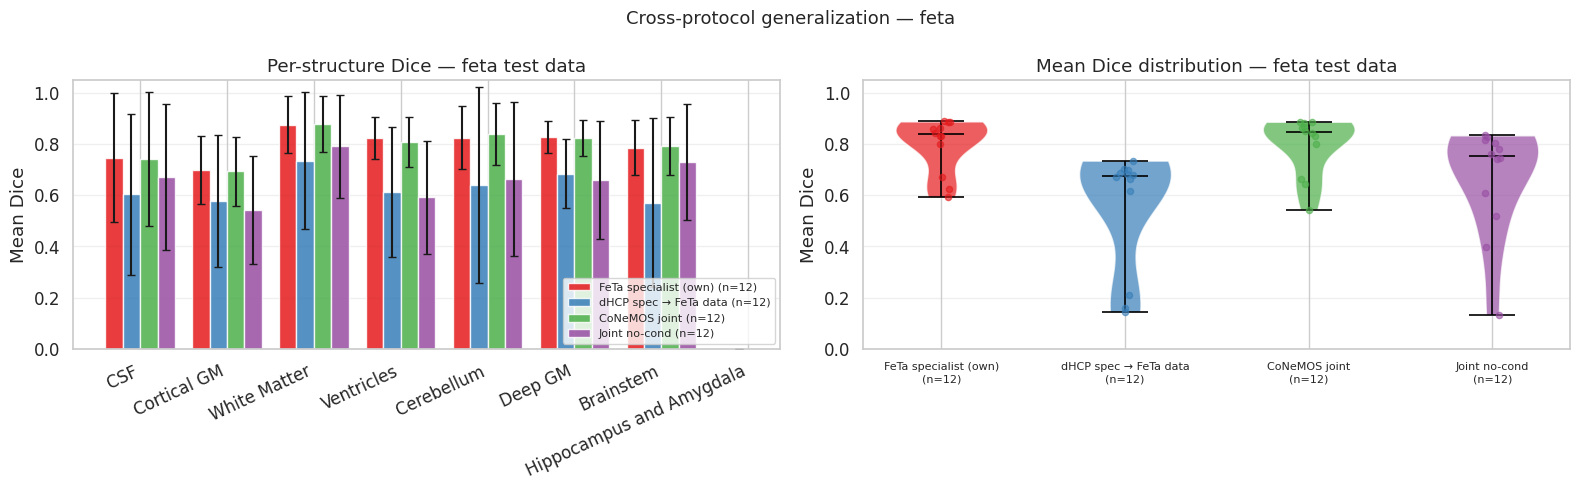


────────────────────────────────────────────────────────────
feta
  Model                          Mean Dice     ± std
  FeTa specialist (own)             0.7971    0.1061
  dHCP spec → FeTa data             0.5541    0.2327
  CoNeMOS joint                     0.7959    0.1141
  Joint no-cond                     0.6636    0.2155

  [skipped] FeTa spec → dHCP data: not found


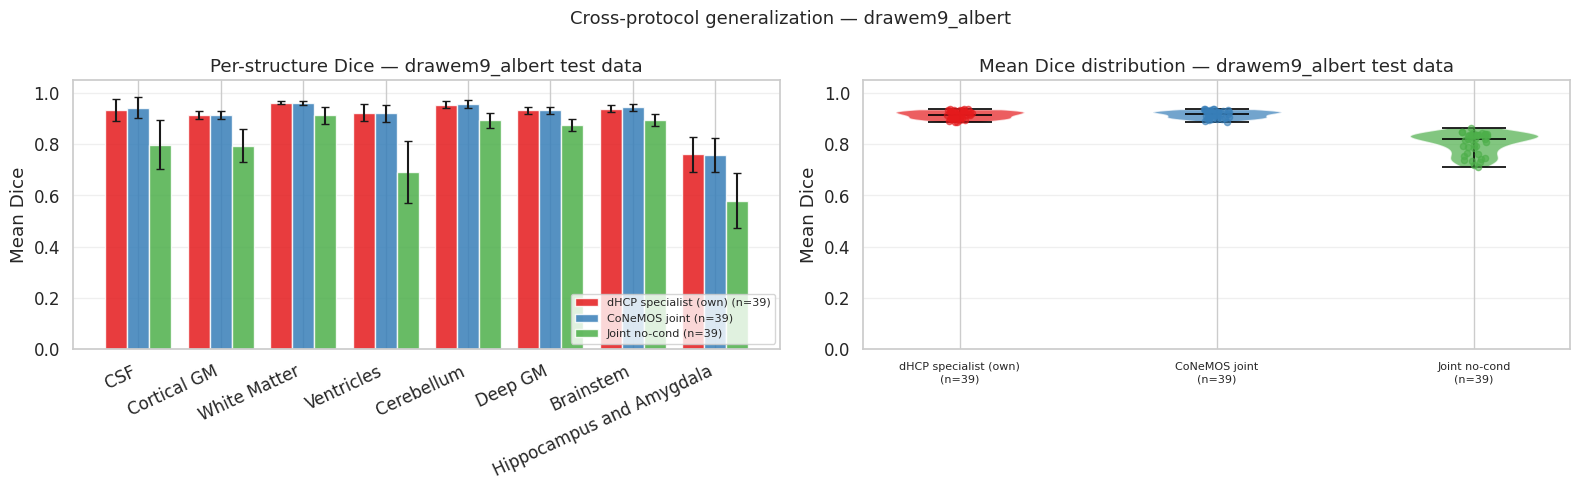


────────────────────────────────────────────────────────────
drawem9_albert
  Model                          Mean Dice     ± std
  dHCP specialist (own)             0.9142    0.0151
  CoNeMOS joint                     0.9155    0.0145
  Joint no-cond                     0.8037    0.0426



In [ ]:
SPECIALIST_CROSS = {
    'feta': [
        ('FeTa specialist (own)',  '../eval_results/feta_specialist_conemos/results.csv'),
        ('dHCP spec → FeTa data', '../eval_results/dhcp_specialist_feta_conemos/results.csv'),
        ('CoNeMOS joint',          '../eval_results/conemos/results.csv'),
        ('Joint no-cond',          '../eval_results/joint_nocond_real/results.csv'),
    ],
    'drawem9_albert': [
        ('dHCP specialist (own)',  '../eval_results/dhcp_specialist_conemos/results.csv'),
        ('FeTa spec → dHCP data', '../eval_results/feta_specialist_conemos_dhcp/results.csv'),
        ('CoNeMOS joint',          '../eval_results/conemos/results.csv'),
        ('Joint no-cond',          '../eval_results/joint_nocond_real/results.csv'),
    ],
}

# Okabe-Ito: specialist-own, cross-specialist, CoNeMOS joint, Joint no-cond
cross_palette = ['#009E73', '#D55E00', '#E69F00', '#CC79A7']

for proto, sources in SPECIALIST_CROSS.items():
    models = []
    for name, path in sources:
        try:
            d = _load_and_normalize(path)
            d = d[d.protocol == proto]
            if len(d):
                models.append((name, d))
        except FileNotFoundError:
            print(f'  [skipped] {name}: not found')

    if not models:
        continue

    n_models = len(models)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── Left: per-structure mean Dice bar chart ──────────────────────────────
    ax = axes[0]
    x  = np.arange(len(struct_names))
    w  = 0.8 / n_models
    for i, (name, d) in enumerate(models):
        means = [d[dc].mean() for dc in dice_cols]
        stds  = [d[dc].std()  for dc in dice_cols]
        ax.bar(x + i * w, means, w, label=f'{name} (n={len(d)})',
               color=cross_palette[i], yerr=stds, capsize=3, alpha=0.85)
    ax.set_xticks(x + w * (n_models - 1) / 2)
    ax.set_xticklabels(struct_names, rotation=25, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Mean Dice')
    ax.set_title(f'Per-structure Dice — {proto} test data')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')

    # ── Right: mean Dice per subject (violin) ────────────────────────────────
    ax = axes[1]
    vdata  = [d['mean_dice'].dropna().values for _, d in models]
    vlabel = [f'{name}\n(n={len(d)})' for name, d in models]
    parts  = ax.violinplot(vdata, positions=range(n_models), showmedians=True, showextrema=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(cross_palette[i])
        pc.set_alpha(0.7)
    for coll in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
        if coll in parts:
            parts[coll].set_color('black')
            parts[coll].set_linewidth(1.2)
    for i, vals in enumerate(vdata):
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.05, 0.05, len(vals)),
                   vals, color=cross_palette[i], s=20, alpha=0.6, zorder=3)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(vlabel, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Mean Dice')
    ax.set_title(f'Mean Dice distribution — {proto} test data')
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Cross-protocol generalization — {proto}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Summary numbers ──────────────────────────────────────────────────────
    print(f'\n{"─"*60}\n{proto}')
    print(f'  {"Model":<28}  {"Mean Dice":>10}  {"± std":>8}')
    for name, d in models:
        print(f'  {name:<28}  {d["mean_dice"].mean():>10.4f}  {d["mean_dice"].std():>8.4f}')
    print()